# **Import Libraries and Data**
---

In [1]:
import pandas as pd
import numpy as np
import string
from string import digits
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import re
from sklearn.model_selection import train_test_split

from keras.layers import Input, LSTM, Embedding, Dense, Bidirectional, Concatenate, Dot, Activation, TimeDistributed
from keras.models import Model
from keras.utils import plot_model

In [2]:
!wget http://www.manythings.org/anki/fra-eng.zip
!unzip fra-eng.zip -d fra-eng

--2025-05-03 21:05:15--  http://www.manythings.org/anki/fra-eng.zip
Resolving www.manythings.org (www.manythings.org)... 173.254.30.110
Connecting to www.manythings.org (www.manythings.org)|173.254.30.110|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7943074 (7.6M) [application/zip]
Saving to: ‘fra-eng.zip.1’

fra-eng.zip.1       100%[===================>]   7.57M  6.63MB/s    in 1.1s    

2025-05-03 21:05:17 (6.63 MB/s) - ‘fra-eng.zip.1’ saved [7943074/7943074]

Archive:  fra-eng.zip
replace fra-eng/_about.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fra-eng/_about.txt      
replace fra-eng/fra.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fra-eng/fra.txt         


# **Data Preparing**
---

In [3]:
data_path = 'fra-eng/fra.txt'
with open(data_path, 'r', encoding='utf-8') as f:
    lines = f.read().split('\n')

lines[:5]

['Go.\tVa !\tCC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #1158250 (Wittydev)',
 'Go.\tMarche.\tCC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #8090732 (Micsmithel)',
 'Go.\tEn route !\tCC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #8267435 (felix63)',
 'Go.\tBouge !\tCC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #9022935 (Micsmithel)',
 'Hi.\tSalut !\tCC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #509819 (Aiji)']

In [4]:
inputs = []
targets = []
num_samples = 10000  # Number of samples to train on.
for line in lines[: min(num_samples, len(lines) - 1)]:
  input, target, _ = line.split('\t')
  inputs.append(input)
  targets.append(target)

print(inputs [:5])
print(targets[:5])

['Go.', 'Go.', 'Go.', 'Go.', 'Hi.']
['Va !', 'Marche.', 'En route !', 'Bouge !', 'Salut !']


In [5]:
lines = pd.DataFrame({'input':inputs, 'target':targets})
num_samples = 10000
lines = lines[0:num_samples]
lines.shape

(10000, 2)

In [6]:
lines.head(10)

,input,target
0,Go.,Va !
1,Go.,Marche.
2,Go.,En route !
3,Go.,Bouge !
4,Hi.,Salut !
5,Hi.,Salut.
6,Run!,Cours !
7,Run!,Courez !
8,Run!,Prenez vos jambes à vos cous !
9,Run!,File !


In [7]:
def cleanup(lines):
  # Reduced the size of vocabulary by converting all words to lower case
  lines.input=lines.input.apply(lambda x: x.lower())
  lines.target=lines.target.apply(lambda x: x.lower())

  # To help the model capture the word separations, mark the comma with special token:
  lines.input=lines.input.apply(lambda x: re.sub("'", '', x)).apply(lambda x: re.sub(",", ' COMMA', x))
  lines.target=lines.target.apply(lambda x: re.sub("'", '', x)).apply(lambda x: re.sub(",", ' COMMA', x))

  # Clean up punctuations and digits. Such special chars are common to both domains, and can just be copied with no error.
  exclude = set(string.punctuation)
  lines.input=lines.input.apply(lambda x: ''.join(ch for ch in x if ch not in exclude))
  lines.target=lines.target.apply(lambda x: ''.join(ch for ch in x if ch not in exclude))

  remove_digits = str.maketrans('', '', digits)
  lines.input=lines.input.apply(lambda x: x.translate(remove_digits))
  lines.target=lines.target.apply(lambda x: x.translate(remove_digits))

  return lines


In [8]:
st_tok = 'START_'
end_tok = '_END'
def data_prep(lines):
  cleanup(lines)
  lines.target = lines.target.apply(lambda x : st_tok + ' ' + x + ' ' + end_tok)

In [9]:
data_prep(lines)
lines.head(20)

,input,target
0,go,START_ va _END
1,go,START_ marche _END
2,go,START_ en route _END
3,go,START_ bouge _END
4,hi,START_ salut _END
5,hi,START_ salut _END
6,run,START_ cours _END
7,run,START_ courez _END
8,run,START_ prenez vos jambes à vos cous _END
9,run,START_ file _END


# **Data Preprocessing**
--------

**Tokenization**

In [10]:
def tok_split_word2word(data):
    return data.split()

def data_stats(lines, input_tok_split_fn, target_tok_split_fn):
    # Get unique tokens using set comprehensions
    input_tokens = set(tok for line in lines.input for tok in input_tok_split_fn(line))
    target_tokens = set(tok for line in lines.target for tok in target_tok_split_fn(line))

    # Convert to sorted lists
    input_tokens = sorted(input_tokens)
    target_tokens = sorted(target_tokens)

    # Calculate lengths
    num_encoder_tokens = len(input_tokens)
    num_decoder_tokens = len(target_tokens)
    max_encoder_seq_length = max(len(input_tok_split_fn(line)) for line in lines.input)
    max_decoder_seq_length = max(len(target_tok_split_fn(line)) for line in lines.target)

    return (input_tokens, target_tokens, num_encoder_tokens,num_decoder_tokens, max_encoder_seq_length, max_decoder_seq_length)

In [11]:
input_tokens, target_tokens, num_encoder_tokens, num_decoder_tokens, max_encoder_seq_length, max_decoder_seq_length = data_stats(
    lines, input_tok_split_fn=tok_split_word2word, target_tok_split_fn=tok_split_word2word)

print('Number of samples:', len(lines))
print('Number of unique input tokens:', num_encoder_tokens)
print('Number of unique output tokens:', num_decoder_tokens)
print('Max sequence length for inputs:', max_encoder_seq_length)
print('Max sequence length for outputs:', max_decoder_seq_length)

Number of samples: 10000
Number of unique input tokens: 2022
Number of unique output tokens: 4412
Max sequence length for inputs: 5
Max sequence length for outputs: 12


**Vocab**

In [12]:
pad_tok = 'PAD'
sep_tok = ' '
special_tokens = [pad_tok, sep_tok, st_tok, end_tok]
num_encoder_tokens += len(special_tokens)
num_decoder_tokens += len(special_tokens)

In [13]:
def vocab(input_tokens, target_tokens):

  input_token_index = {}
  target_token_index = {}
  for i,tok in enumerate(special_tokens):
    input_token_index[tok] = i
    target_token_index[tok] = i

  offset = len(special_tokens)
  for i, tok in enumerate(input_tokens):
    input_token_index[tok] = i+offset

  for i, tok in enumerate(target_tokens):
    target_token_index[tok] = i+offset

  # Reverse-lookup token index to decode sequences back to something readable.
  reverse_input_tok_index = dict(
      (i, tok) for tok, i in input_token_index.items())
  reverse_target_tok_index = dict(
      (i, tok) for tok, i in target_token_index.items())
  return input_token_index, target_token_index, reverse_input_tok_index, reverse_target_tok_index

In [14]:
input_token_index, target_token_index, reverse_input_tok_index, reverse_target_tok_index = vocab(input_tokens, target_tokens)

**Vectorization**

In [15]:
max_encoder_seq_length = 16
max_decoder_seq_length = 16

In [16]:
def init_model_inputs(lines, max_encoder_seq_length, max_decoder_seq_length, num_decoder_tokens):
  encoder_input_data = np.zeros(
      (len(lines.input), max_encoder_seq_length),
      dtype='float32')
  decoder_input_data = np.zeros(
      (len(lines.target), max_decoder_seq_length),
      dtype='float32')
  decoder_target_data = np.zeros(
      (len(lines.target), max_decoder_seq_length, num_decoder_tokens),
      dtype='float32')

  return encoder_input_data, decoder_input_data, decoder_target_data

In [17]:
def vectorize(lines, max_encoder_seq_length, max_decoder_seq_length, num_decoder_tokens, input_tok_split_fn, target_tok_split_fn):
  encoder_input_data, decoder_input_data, decoder_target_data = init_model_inputs(lines, max_encoder_seq_length, max_decoder_seq_length, num_decoder_tokens)
  for i, (input_text, target_text) in enumerate(zip(lines.input, lines.target)):
      for t, tok in enumerate(input_tok_split_fn(input_text)):
          encoder_input_data[i, t] = input_token_index[tok]
      encoder_input_data[i, t+1:] = input_token_index[pad_tok]
      for t, tok in enumerate(target_tok_split_fn(target_text)):
          # decoder_target_data is ahead of decoder_input_data by one timestep
          decoder_input_data[i, t] = target_token_index[tok]
          if t > 0:
              # decoder_target_data will be ahead by one timestep
              # and will not include the start character.
              decoder_target_data[i, t - 1, target_token_index[tok]] = 1.
      decoder_input_data[i, t+1:] = target_token_index[pad_tok]
      decoder_target_data[i, t:, target_token_index[pad_tok]] = 1.

  return encoder_input_data, decoder_input_data, decoder_target_data

In [18]:
encoder_input_data, decoder_input_data, decoder_target_data  = vectorize(lines, max_encoder_seq_length, max_decoder_seq_length, num_decoder_tokens, input_tok_split_fn=tok_split_word2word, target_tok_split_fn=tok_split_word2word)

In [19]:
encoder_input_data.shape, decoder_input_data.shape, decoder_target_data.shape

((10000, 16), (10000, 16), (10000, 16, 4416))

# **Modelling**

In [20]:
def seq2seq_attention(num_encoder_tokens, num_decoder_tokens, emb_sz, latent_dim):
    # Define an input sequence and process it.
    encoder_inputs = Input(shape=(None,), dtype='float32')
    encoder_inputs_ = Embedding(num_encoder_tokens, emb_sz, mask_zero=True)(encoder_inputs)

    encoder = Bidirectional(LSTM(latent_dim, return_state=True, return_sequences=True)) # Bi LSTM
    encoder_outputs, state_f_h, state_f_c, state_b_h, state_b_c = encoder(encoder_inputs_)# Bi LSTM
    state_h = Concatenate()([state_f_h, state_b_h])# Bi LSTM
    state_c = Concatenate()([state_f_c, state_b_c])# Bi LSTM

    # We discard `encoder_outputs` and only keep the states.
    encoder_states = [state_h, state_c]# Bi GRU, LSTM, BHi LSTM
    print(encoder_states)

    decoder_inputs = Input(shape=(None,))
    decoder_inputs_ = Embedding(num_decoder_tokens, emb_sz, mask_zero=True)(decoder_inputs)
    # We set up our decoder to return full output sequences,
    # and to return internal states as well. We don't use the
    # return states in the training model, but we will use them in inference.
    decoder_lstm = LSTM(latent_dim*2, return_sequences=True, return_state=True)# Bi LSTM

    decoder_outputs, _, _ = decoder_lstm(decoder_inputs_, initial_state=encoder_states)

    # Equation (7) with 'dot' score from Section 3.1 in the paper.
    # Note that we reuse Softmax-activation layer instead of writing tensor calculation
    print(decoder_outputs)
    print(encoder_outputs)
    att_dot = Dot(axes=[2, 2])
    attention = att_dot([decoder_outputs, encoder_outputs])
    att_activation = Activation('softmax', name='attention')
    attention = att_activation(attention)
    print('attention', attention)
    context_dot = Dot(axes=[2,1])
    context = context_dot([attention, encoder_outputs])
    att_context_concat = Concatenate()
    decoder_combined_context = att_context_concat([context, decoder_outputs])

    # Has another weight + tanh layer as described in equation (5) of the paper

    decoder_dense = Dense(num_decoder_tokens, activation='softmax')
    #decoder_outputs = decoder_dense(decoder_outputs)
    decoder_outputs = decoder_dense(decoder_combined_context)

    # Define the model that will turn
    # `encoder_input_data` & `decoder_input_data` into `decoder_target_data`
    model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['acc'])

    print('encoder-decoder  model:')
    print(model.summary())

    print(encoder_inputs)
    print(encoder_outputs)
    print(encoder_states)
    encoder_model = Model(inputs=encoder_inputs, outputs=[encoder_outputs] + encoder_states)

    decoder_encoder_inputs = Input(shape=(None, latent_dim*2,))
    decoder_state_input_h = Input(shape=(latent_dim*2,))# Bi LSTM
    decoder_state_input_c = Input(shape=(latent_dim*2,)) # Bi LSTM

    decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

    decoder_outputs, state_h, state_c = decoder_lstm(decoder_inputs_, initial_state=decoder_states_inputs)


    decoder_states = [state_h, state_c]

    # Equation (7) with 'dot' score from Section 3.1 in the paper.
    # Note that we reuse Softmax-activation layer instead of writing tensor calculation

    attention = att_dot([decoder_outputs, decoder_encoder_inputs])

    attention = att_activation(attention)

    context = context_dot([attention, decoder_encoder_inputs])



    decoder_combined_context = att_context_concat([context, decoder_outputs])

    # Has another weight + tanh layer as described in equation (5) of the paper

    decoder_outputs = decoder_dense(decoder_combined_context)

    decoder_model = Model(
        [decoder_inputs, decoder_encoder_inputs] + decoder_states_inputs,
        [decoder_outputs, attention] + decoder_states)

    return model, encoder_model, decoder_model

[<KerasTensor shape=(None, 512), dtype=float32, sparse=False, name=keras_tensor_8>, <KerasTensor shape=(None, 512), dtype=float32, sparse=False, name=keras_tensor_9>]
<KerasTensor shape=(None, None, 512), dtype=float32, sparse=False, name=keras_tensor_13>
<KerasTensor shape=(None, None, 512), dtype=float32, sparse=False, name=keras_tensor_3>
attention <KerasTensor shape=(None, None, None), dtype=float32, sparse=False, name=keras_tensor_17>
encoder-decoder  model:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    518,656 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ [(None, None,     │  1,050,624 │ embedding[0][0],  │
│ (Bidirectional)     │ 512), (None,      │            │ not_equal[0][0]   │
│                     │ 256), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 256) │  1,130,496 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 512)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │  1,574,912 │ embedding_1[0][0… │
│                     │ 512), (None,      │            │ concatenate[0][0… │
│                     │ 512), (None,      │            │ concatenate_1[0]… │
│                     │ 512)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, None,      │          0 │ lstm_1[0][0],     │
│                     │ None)             │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, None,      │          0 │ dot[0][0]         │
│ (Activation)        │ None)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_1 (Dot)         │ (None, None, 512) │          0 │ attention[0][0],  │
│                     │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, None,      │          0 │ dot_1[0][0],      │
│ (Concatenate)       │ 1024)             │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None,      │  4,526,400 │ concatenate_2[0]… │
│                     │ 4416)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,801,088 (33.57 MB)

 Trainable params: 8,801,088 (33.57 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    518,656 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ [(None, None,     │  1,050,624 │ embedding[0][0],  │
│ (Bidirectional)     │ 512), (None,      │            │ not_equal[0][0]   │
│                     │ 256), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 256) │  1,130,496 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 512)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │  1,574,912 │ embedding_1[0][0… │
│                     │ 512), (None,      │            │ concatenate[0][0… │
│                     │ 512), (None,      │            │ concatenate_1[0]… │
│                     │ 512)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, None,      │          0 │ lstm_1[0][0],     │
│                     │ None)             │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, None,      │          0 │ dot[0][0]         │
│ (Activation)        │ None)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_1 (Dot)         │ (None, None, 512) │          0 │ attention[0][0],  │
│                     │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, None,      │          0 │ dot_1[0][0],      │
│ (Concatenate)       │ 1024)             │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None,      │  4,526,400 │ concatenate_2[0]… │
│                     │ 4416)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,801,088 (33.57 MB)

 Trainable params: 8,801,088 (33.57 MB)

 Non-trainable params: 0 (0.00 B)

None


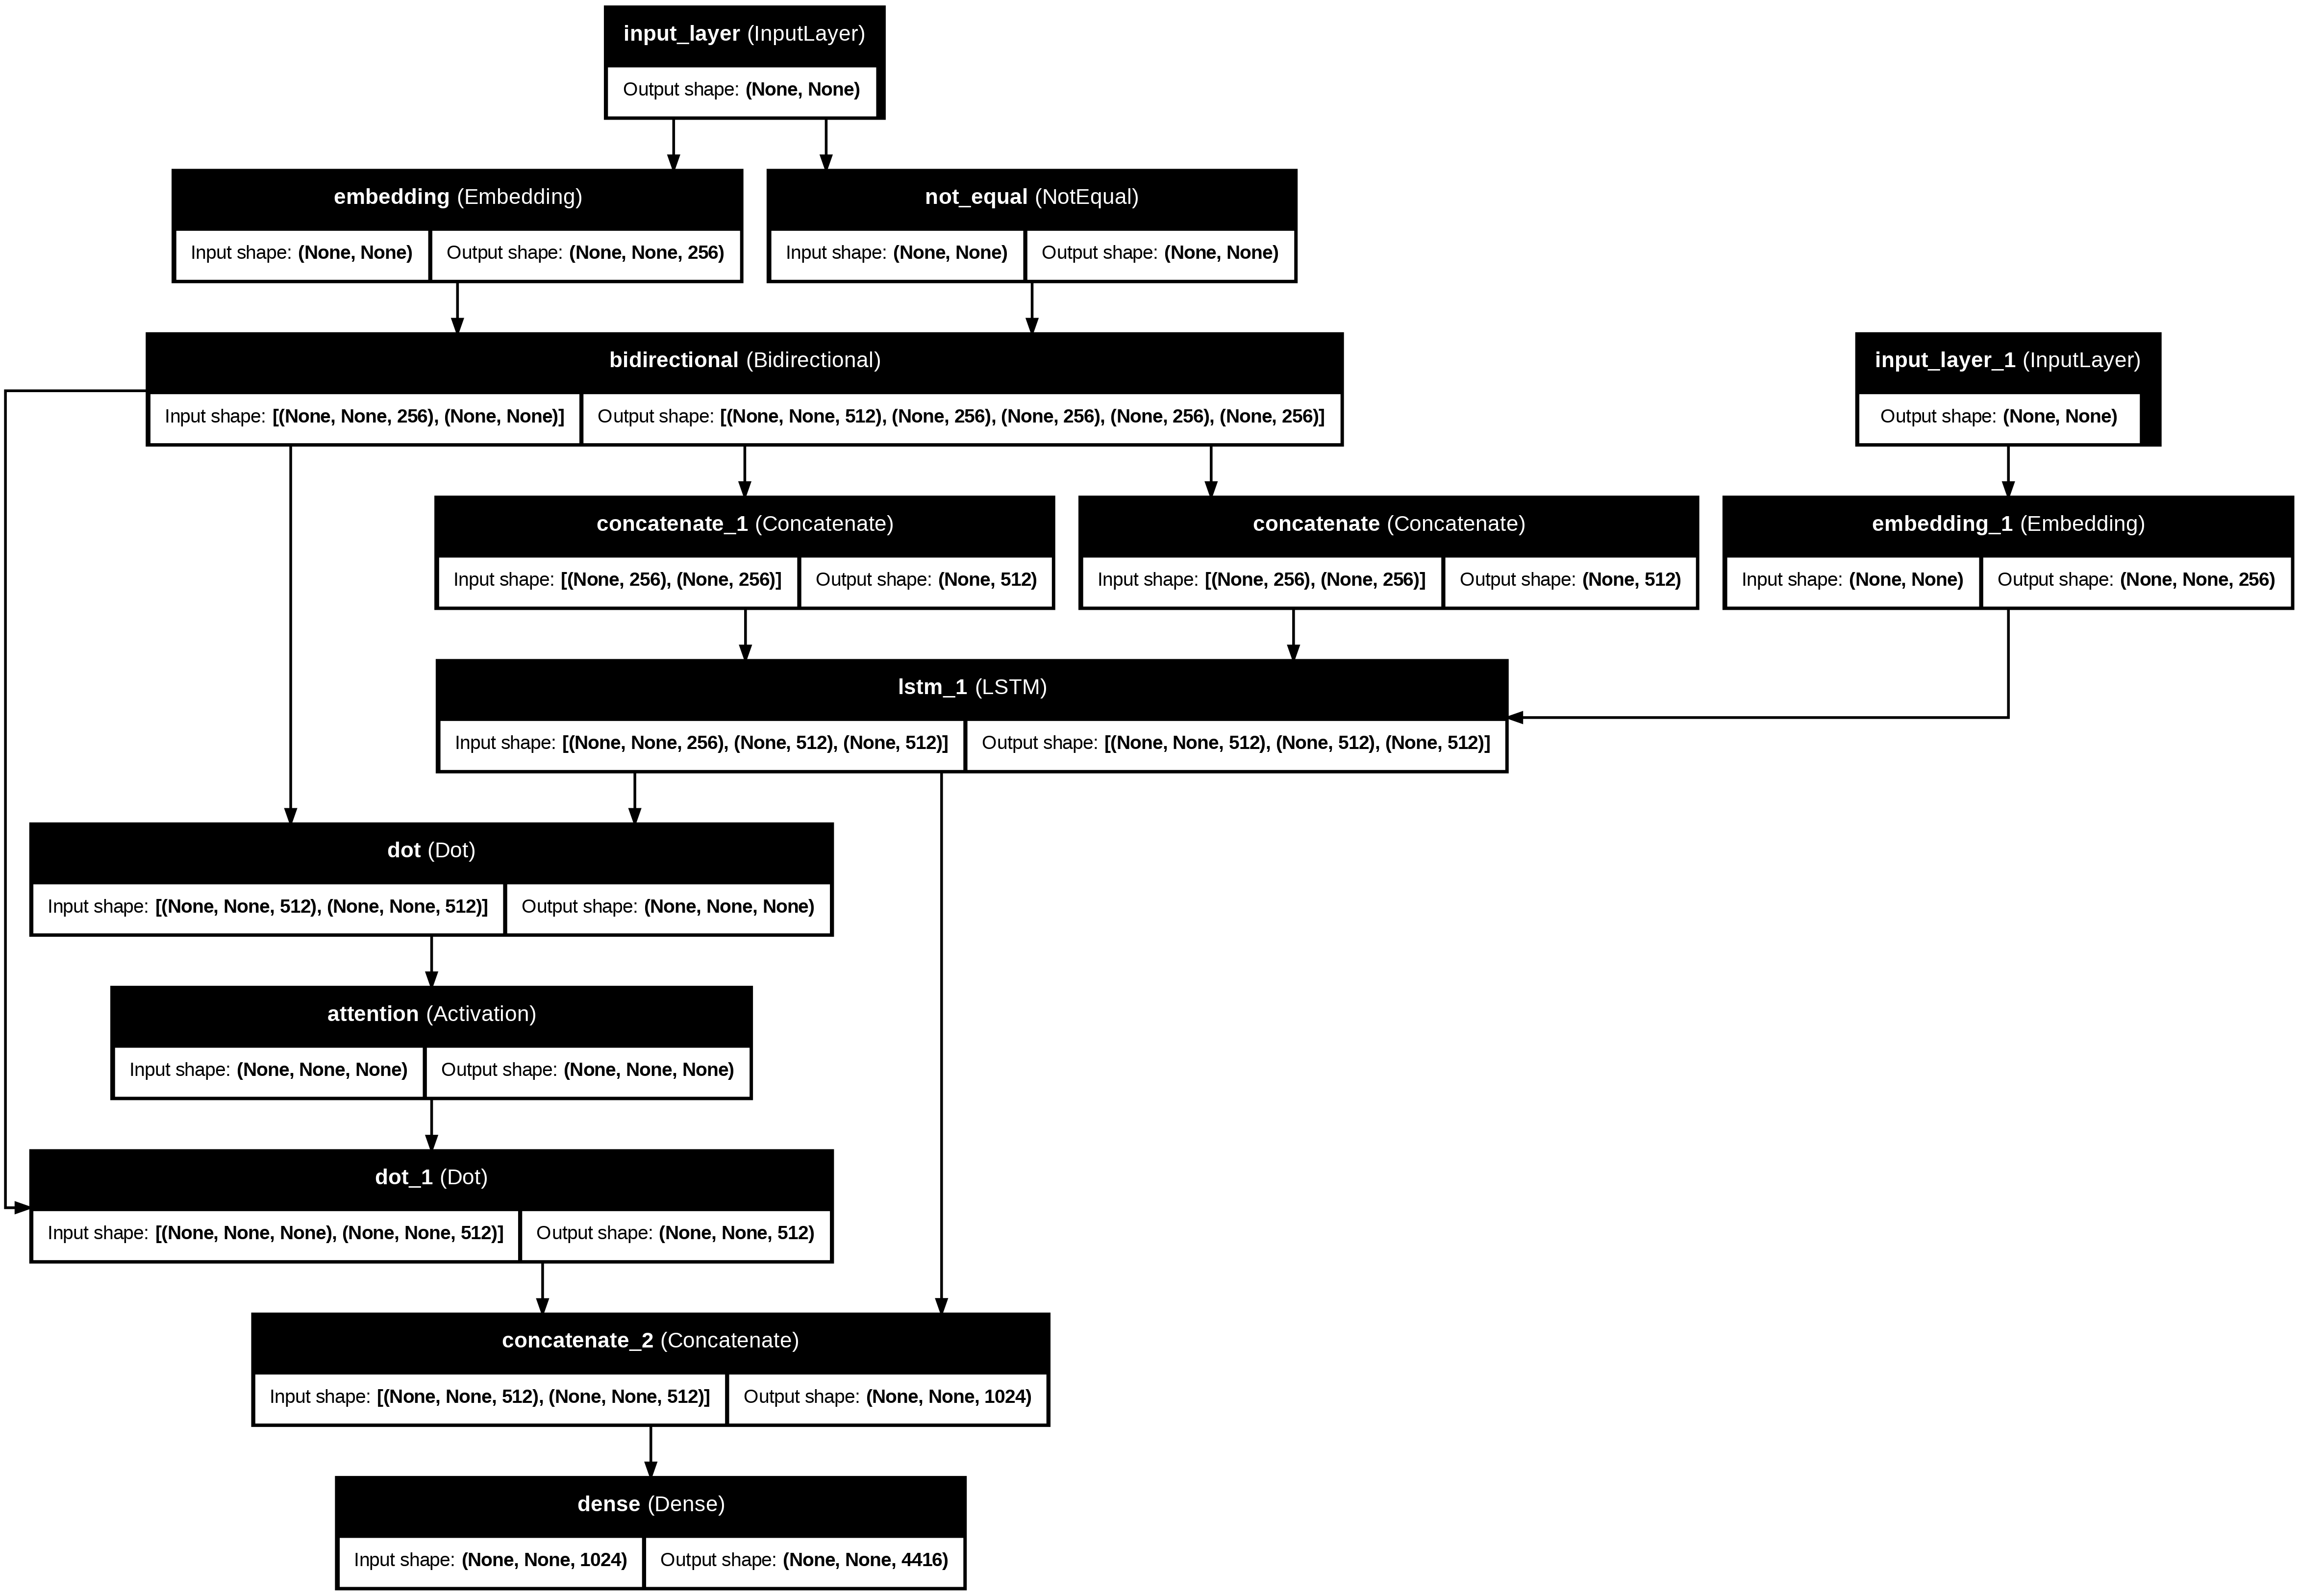

In [21]:
emb_sz = 256
model, encoder_model, decoder_model = seq2seq_attention(num_encoder_tokens, num_decoder_tokens, emb_sz=emb_sz, latent_dim=emb_sz)
print(model.summary())
plot_model(model, show_shapes=True, show_layer_names=True)

In [22]:
model.fit([encoder_input_data, decoder_input_data], decoder_target_data,
          batch_size=128,
          epochs=20,
          validation_split=0.05)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 146ms/step - acc: 0.7058 - loss: 3.1690 - val_acc: 0.7771 - val_loss: 1.5719
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 126ms/step - acc: 0.8211 - loss: 1.3036 - val_acc: 0.7771 - val_loss: 1.4330
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - acc: 0.8267 - loss: 1.2281 - val_acc: 0.7771 - val_loss: 1.4235
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - acc: 0.8285 - loss: 1.2008 - val_acc: 0.7771 - val_loss: 1.4051
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - acc: 0.8315 - loss: 1.1702 - val_acc: 0.7771 - val_loss: 1.3703
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - acc: 0.8348 - loss: 1.1458 - val_acc: 0.8183 - val_loss: 1.3315
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - acc: 0.8359 - loss: 1.1318 - val_acc: 0.8066 - val_loss: 1.3196
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - acc: 0.8364 - loss: 1.1228 - val_acc: 0.8144 - val_loss: 1.2853
Epoch 9/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 128ms/s

# **Inference**
---

In [23]:
def decode_sequence_attention(input_seq, sep=' '):
    # Encode the input as state vectors.
    encoder_outputs, h, c = encoder_model.predict(input_seq)
    states_value = [h,c]
    # Generate empty target sequence of length 1.
    target_seq = np.zeros((1,1))
    # Populate the first character of target sequence with the start character.
    target_seq[0, 0] = target_token_index[st_tok]

    # Sampling loop for a batch of sequences
    # (to simplify, here we assume a batch of size 1).
    stop_condition = False
    decoded_sentence = ''
    attention_density = []
    while not stop_condition:
        output_tokens, attention, h, c  = decoder_model.predict(
            [target_seq, encoder_outputs] + states_value)
        attention_density.append(attention[0][0])# attention is max_sent_len x 1 since we have num_time_steps = 1 for the output
        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_tok = reverse_target_tok_index[sampled_token_index]
        decoded_sentence += sep + sampled_tok

        # Exit condition: either hit max length
        # or find stop character.
        if (sampled_tok == end_tok or
           len(decoded_sentence) > 52):
            stop_condition = True

        # Update the target sequence (of length 1).
        target_seq = np.zeros((1,1))
        target_seq[0, 0] = sampled_token_index

        # Update states
        states_value = [h, c]
    attention_density = np.array(attention_density)
    return decoded_sentence, attention_density

#### Look at the some translations

In [24]:
word_decoded_sents = []
for seq_index in range(15):
    input_seq = encoder_input_data[seq_index: seq_index + 1]
    decoded_sentence, attention = decode_sequence_attention(input_seq)
    print('-')
    print('Input sentence:', lines.input[seq_index: seq_index + 1])
    print('Decoded sentence:', decoded_sentence)
    word_decoded_sents.append(decoded_sentence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
-
Input sentence: 0    go
Name: input, dtype: object
Decoded sentence:  ils sont _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
-
Input sentence: 1    go
Name: input, dtype: object
Decoded sentence:  ils sont _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
-
Input sentence: 2    go
Name: input, dtype: object
Decoded sentence:  ils sont _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
-
Input sentence: 3    go
Name: input, dtype: object
Decoded sentence:  ils sont _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━

In [25]:
def visualize_attention(text, encoder_model, decoder_model, max_encoder_seq_length, num_decoder_tokens, vocab_to_int, int_to_vocab, tok_split_fn, sep= ' '):

    encoder_input_data = np.zeros((1, max_encoder_seq_length), dtype='float32')

    for t, word in enumerate(tok_split_fn(text)):
        encoder_input_data[0, t] = input_token_index[word]

    input_seq = encoder_input_data[0:1]

    decoded_sentence, attention_density = decode_sequence_attention(input_seq, sep)

    plt.clf()
    plt.figure(figsize=(28,12))

    ax = sns.heatmap(attention_density[:, : len(text) + 2],
        xticklabels=[w for w in tok_split_fn(text)],
        yticklabels=[w for w in tok_split_fn(decoded_sentence)])

    ax.invert_yaxis()
    plt.show()

    return decoded_sentence

-
Input sentence: go
GT sentence: START_ va  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


<Figure size 640x480 with 0 Axes>

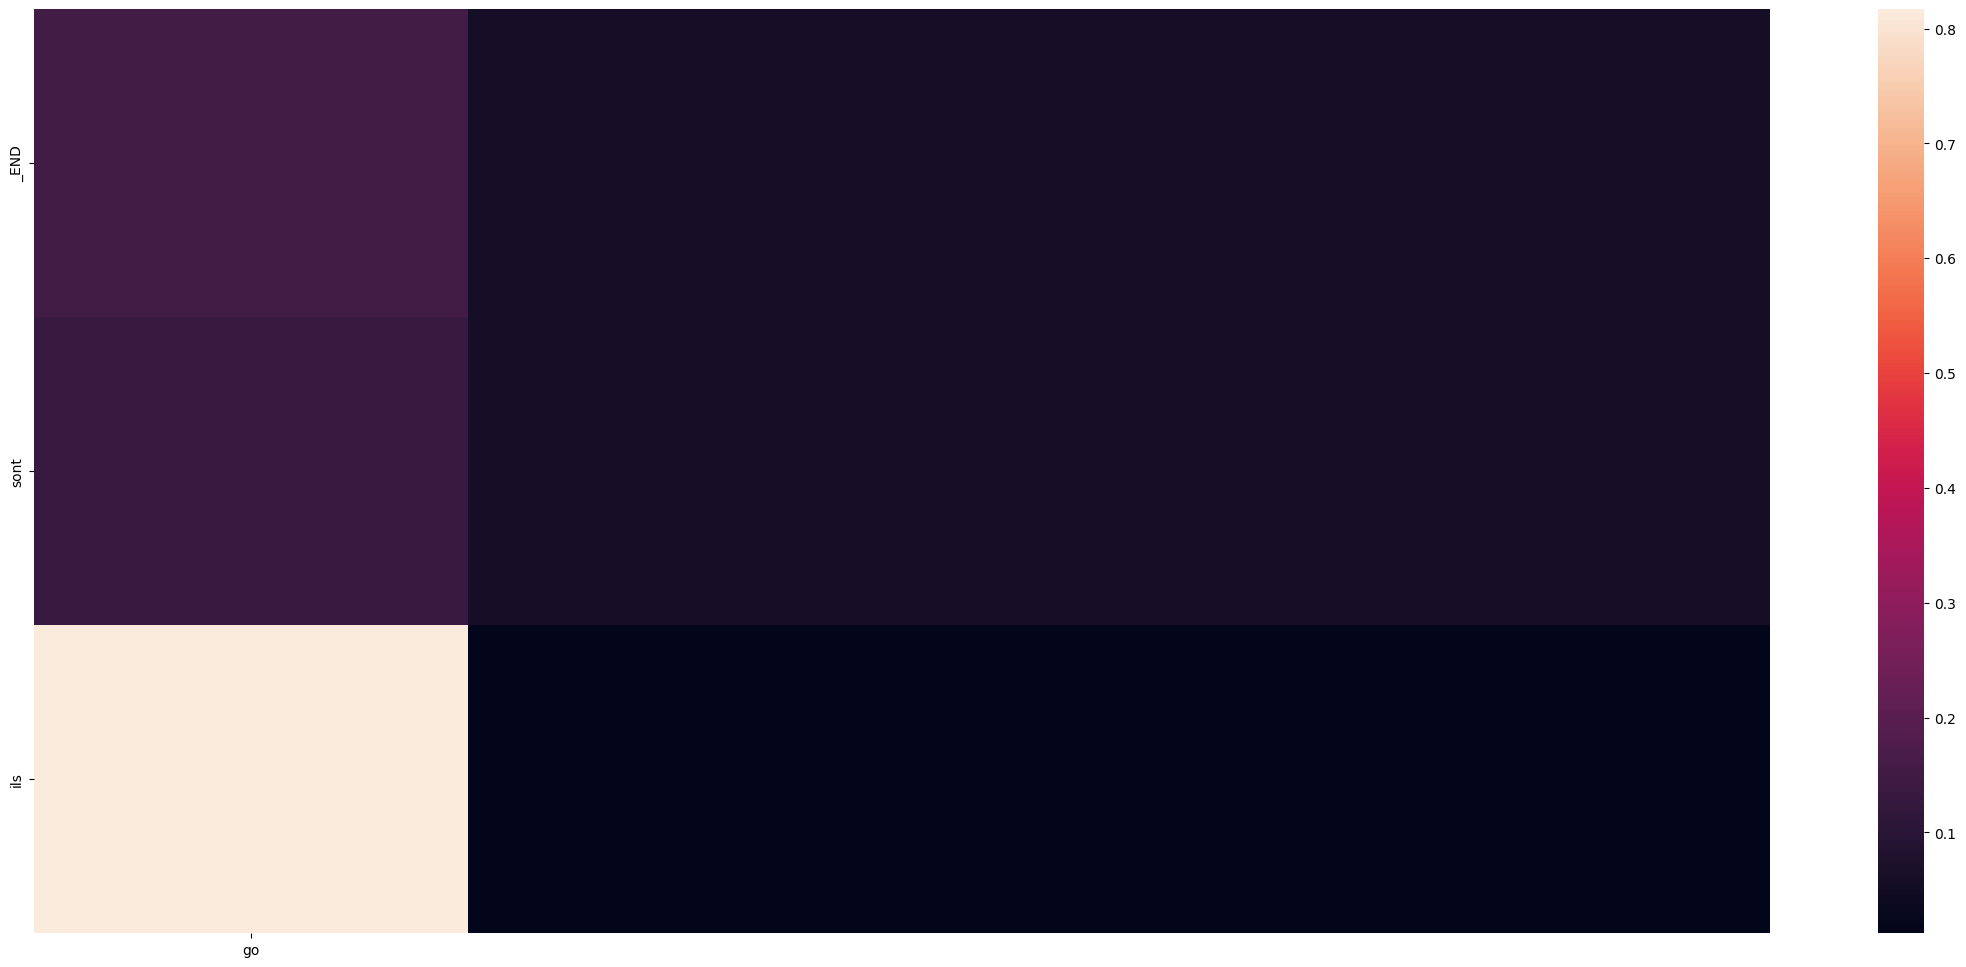

Decoded sentence:  ils sont _END
-
Input sentence: go
GT sentence: START_ marche _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


<Figure size 640x480 with 0 Axes>

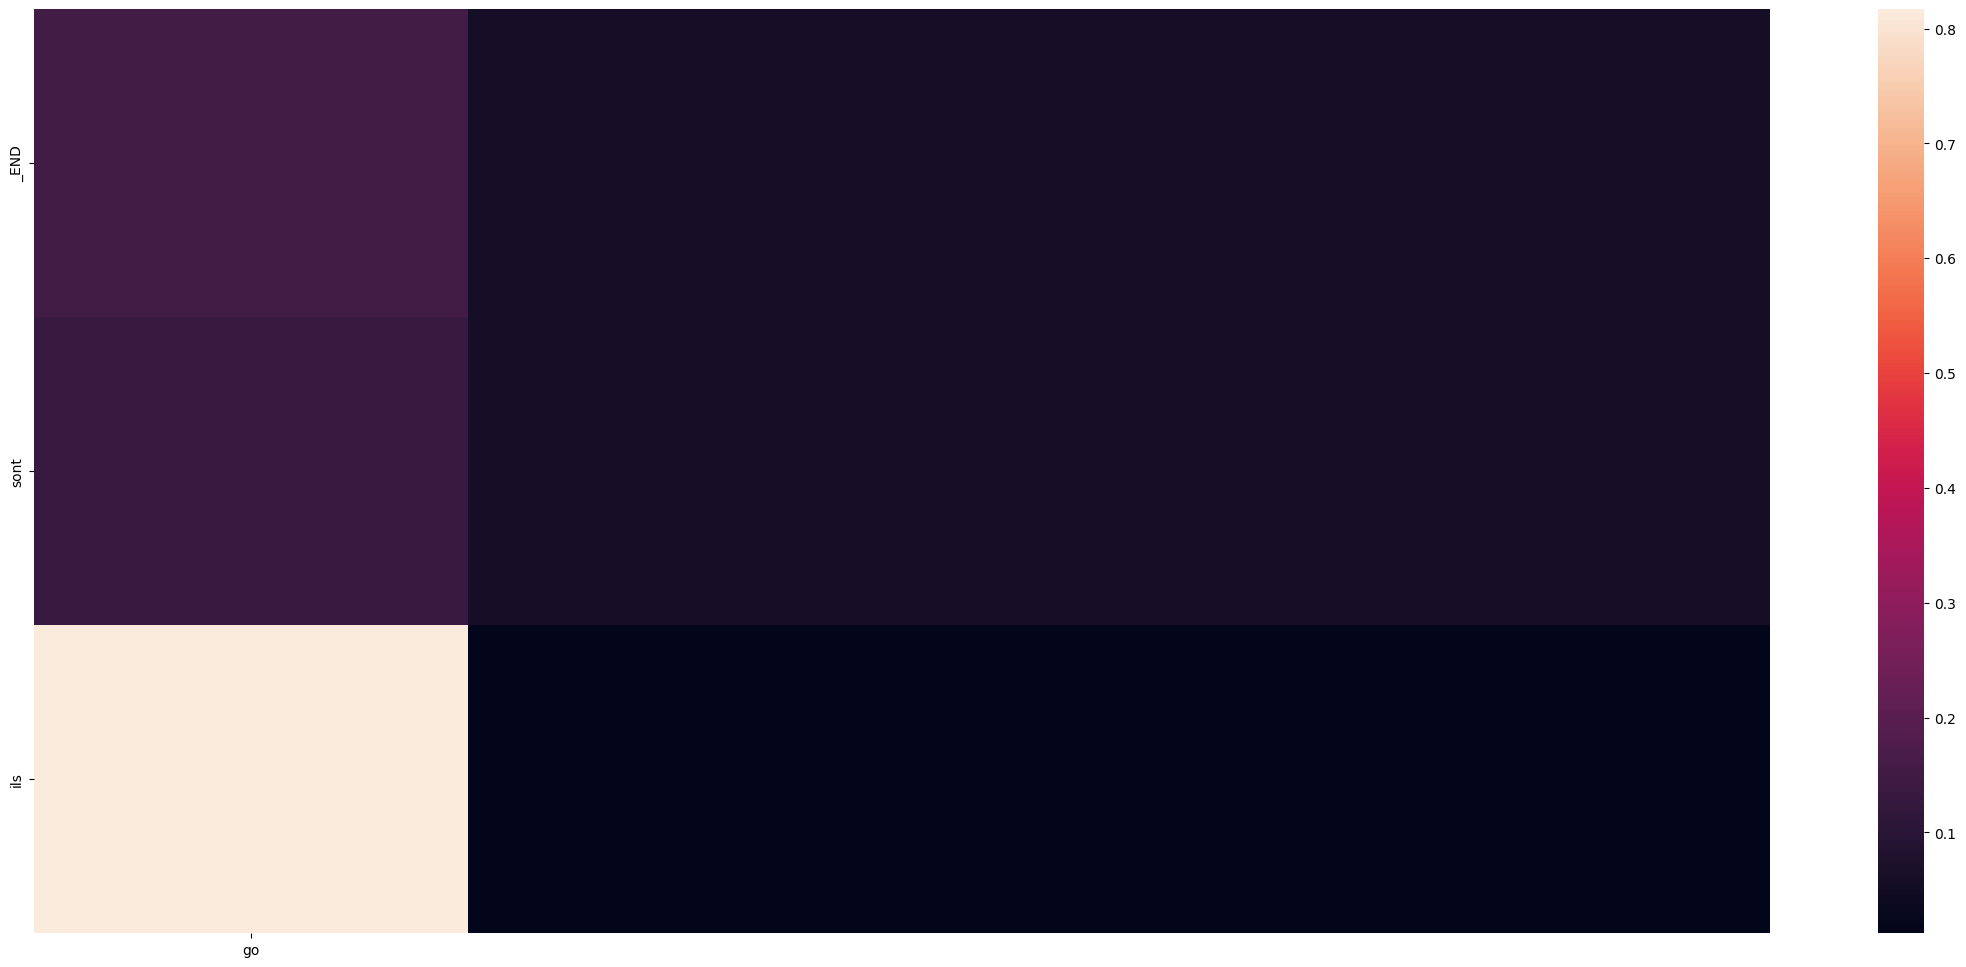

Decoded sentence:  ils sont _END
-
Input sentence: go
GT sentence: START_ en route  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


<Figure size 640x480 with 0 Axes>

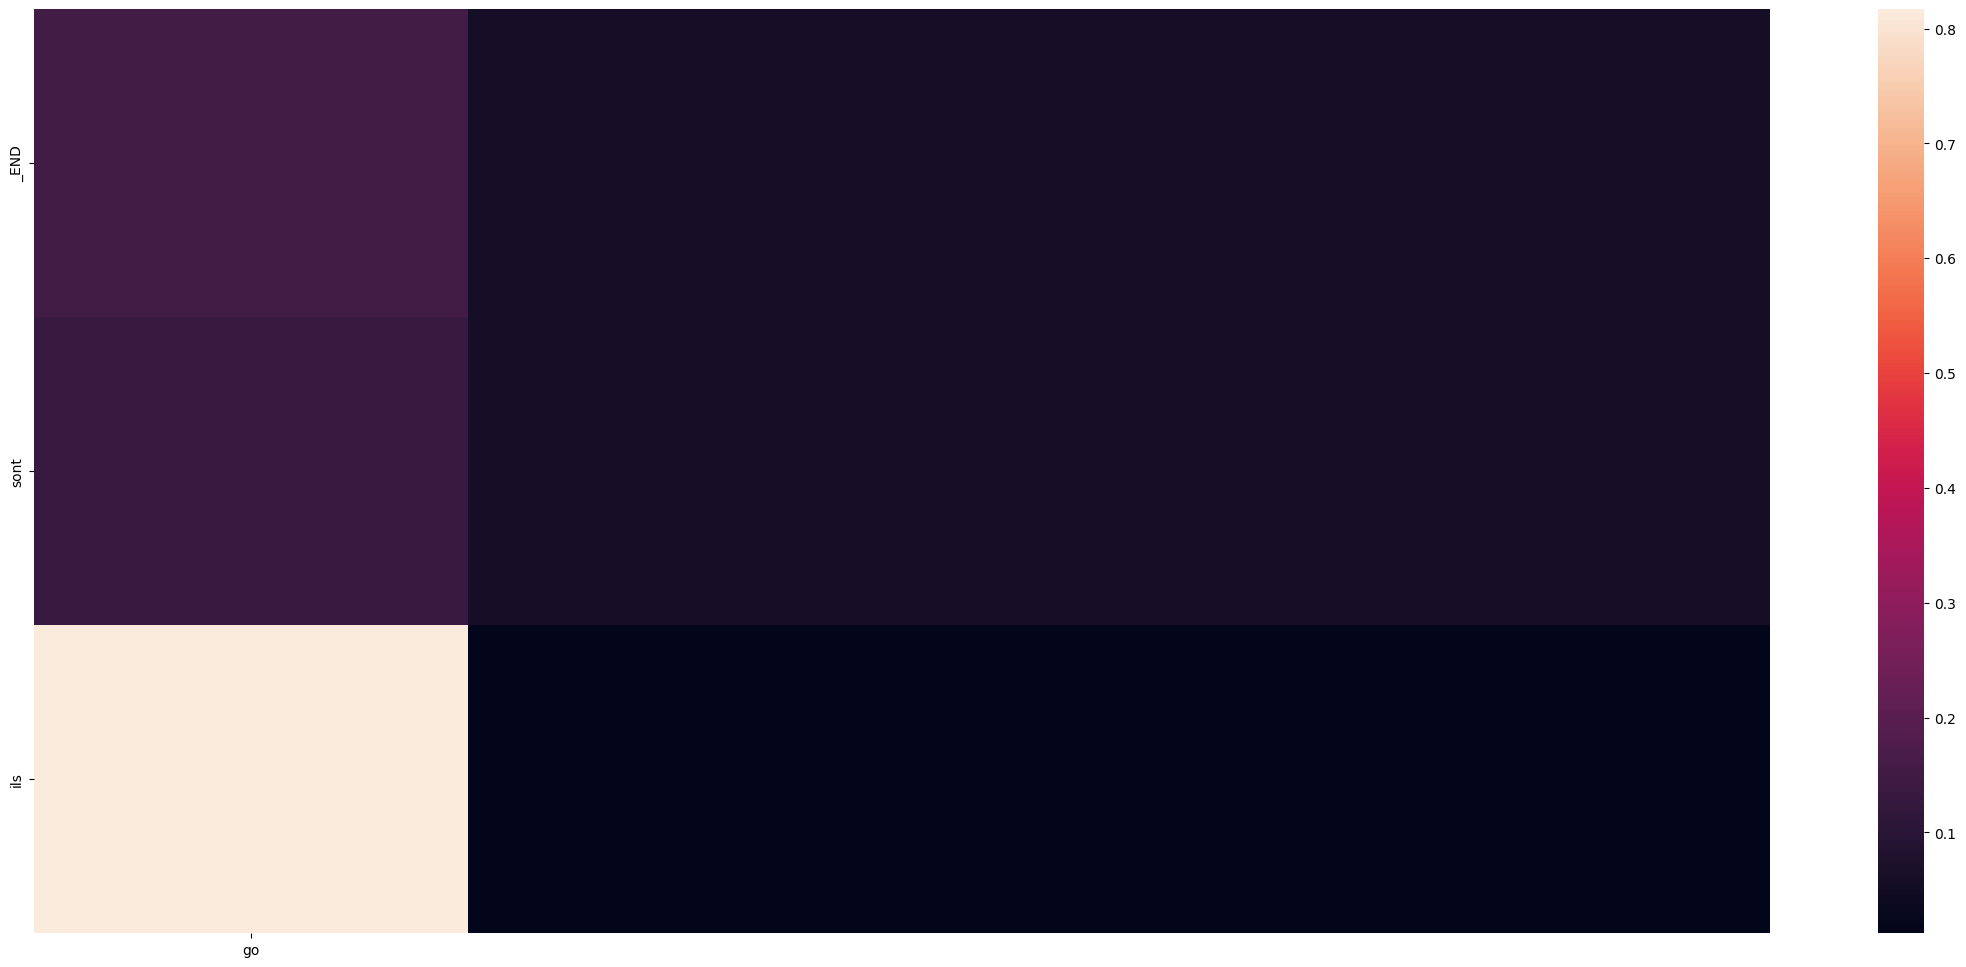

Decoded sentence:  ils sont _END
-
Input sentence: go
GT sentence: START_ bouge  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


<Figure size 640x480 with 0 Axes>

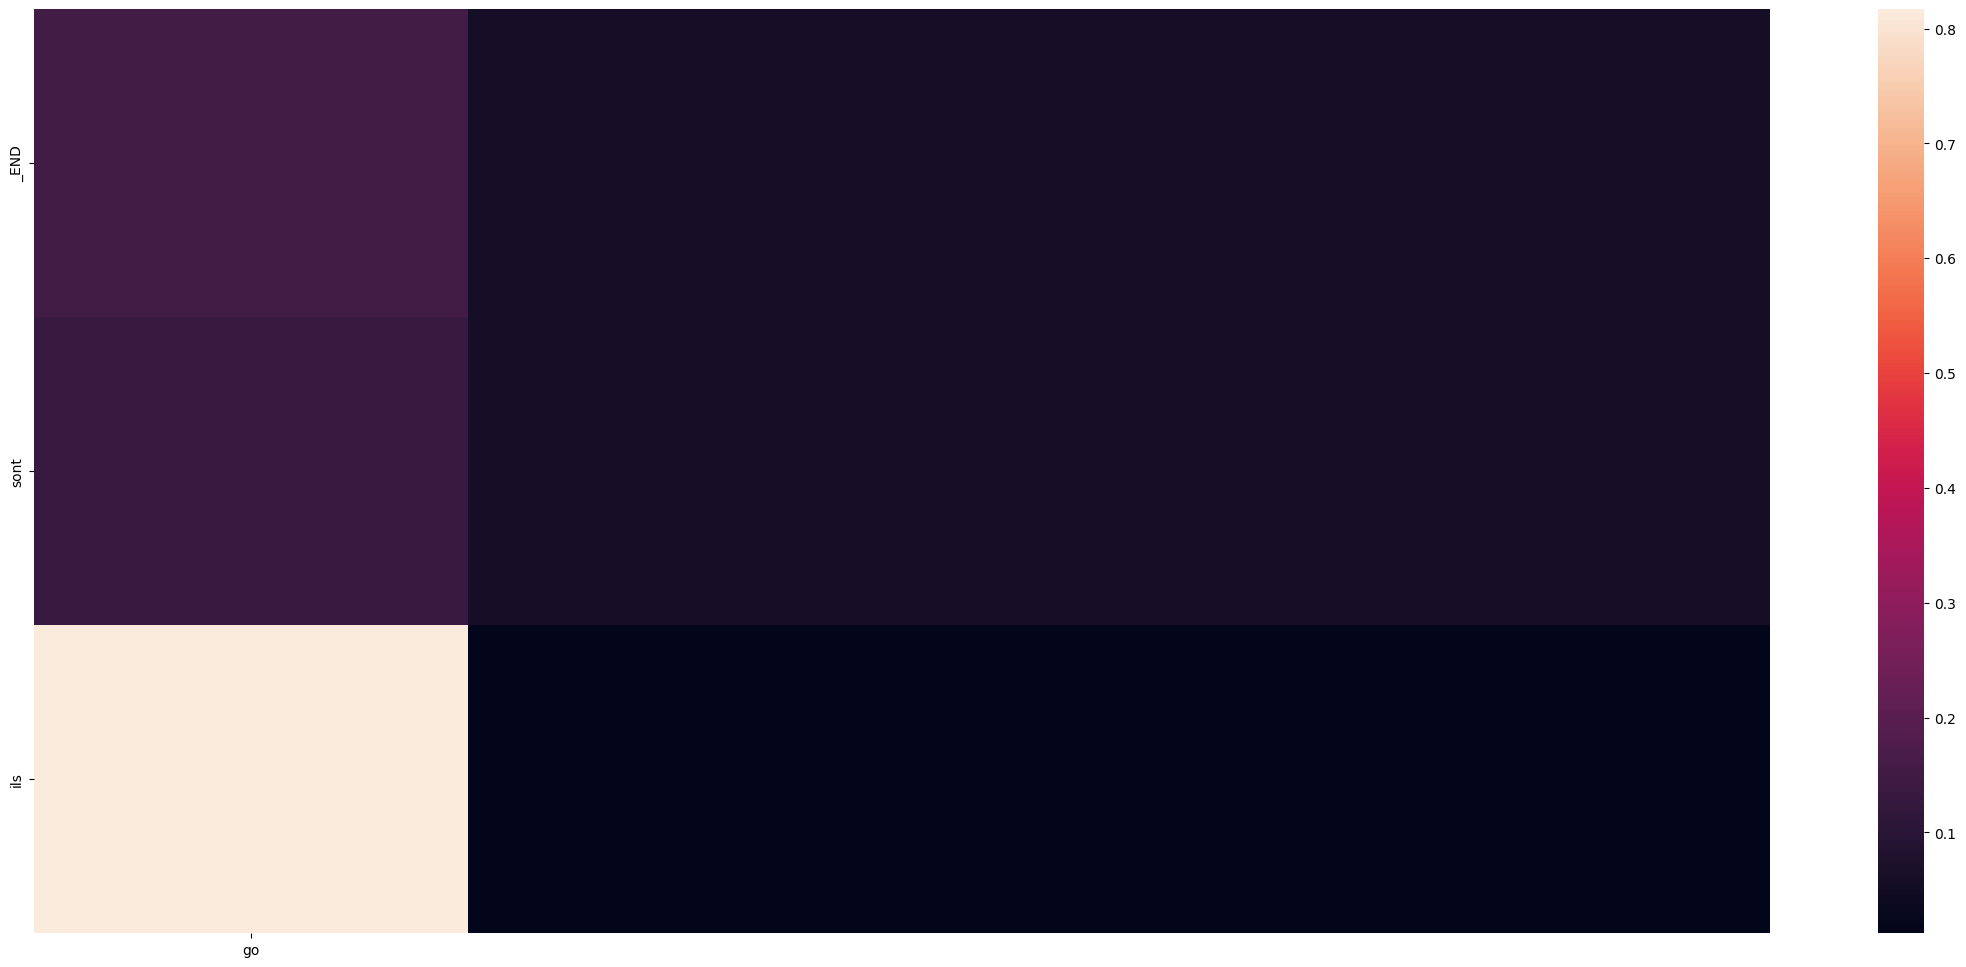

Decoded sentence:  ils sont _END
-
Input sentence: hi
GT sentence: START_ salut  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


<Figure size 640x480 with 0 Axes>

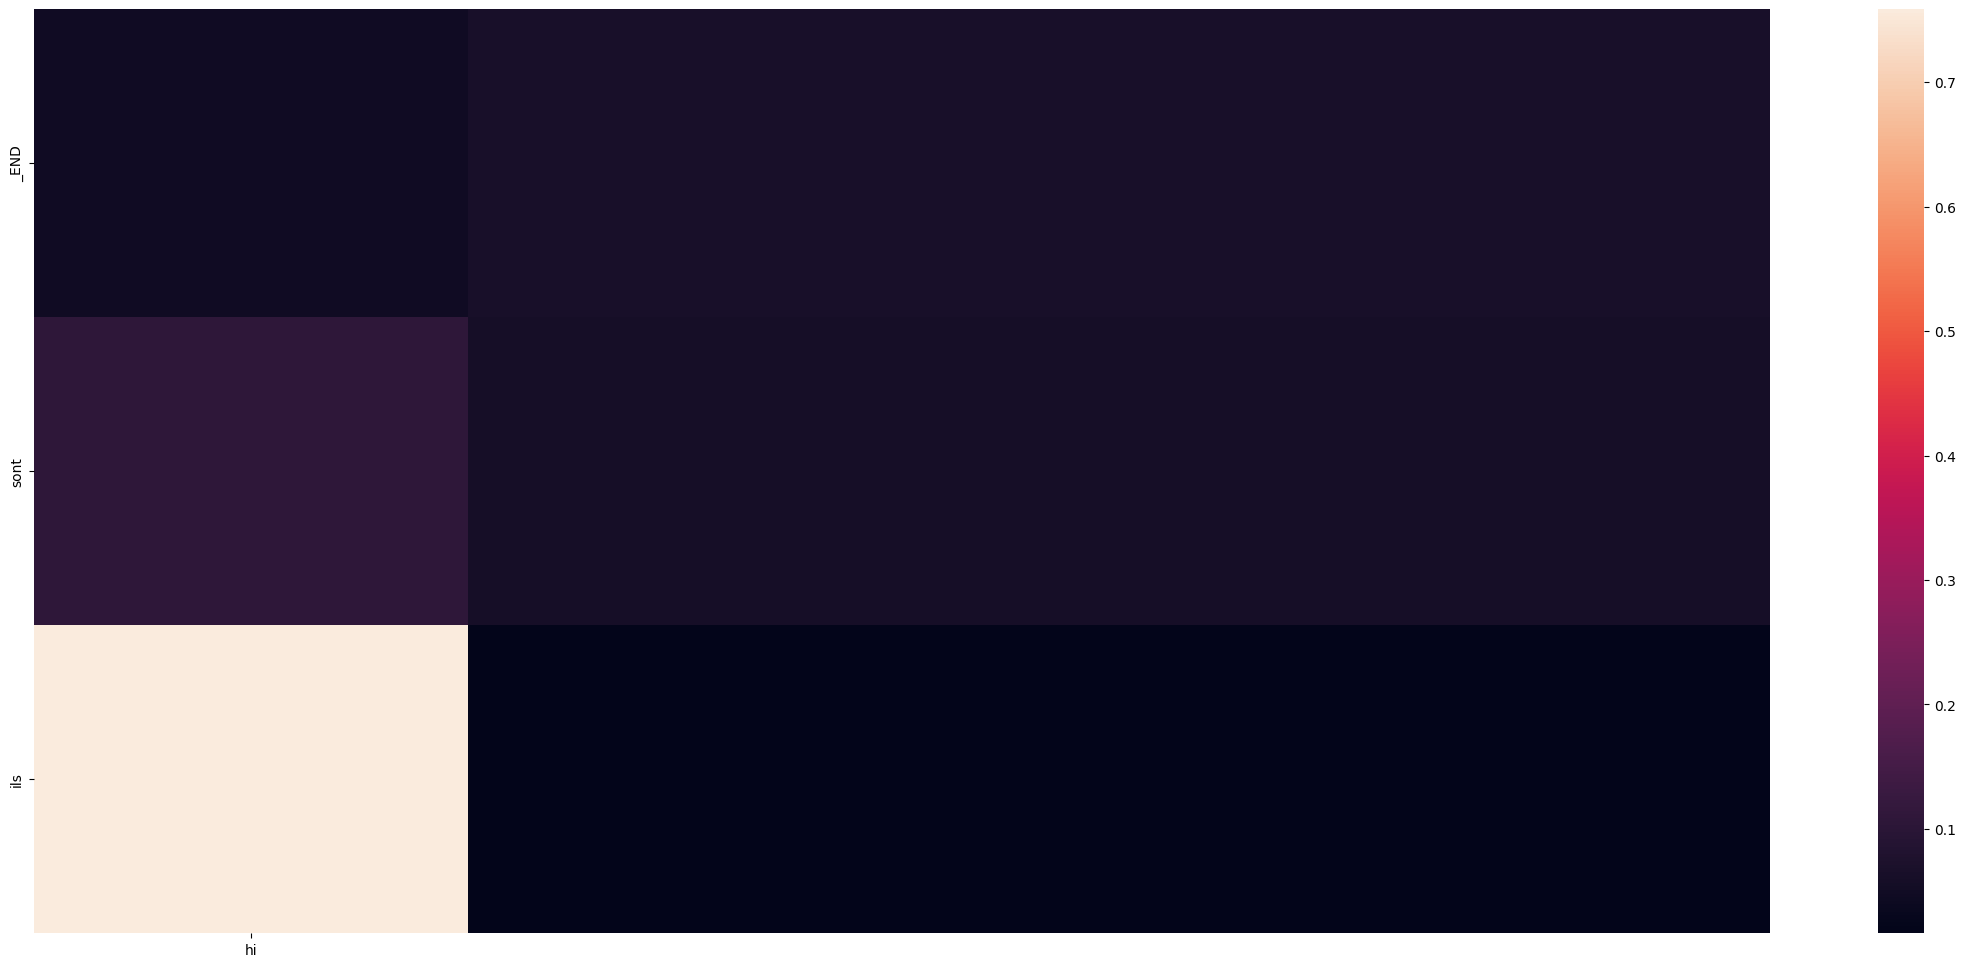

Decoded sentence:  ils sont _END
-
Input sentence: hi
GT sentence: START_ salut _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


<Figure size 640x480 with 0 Axes>

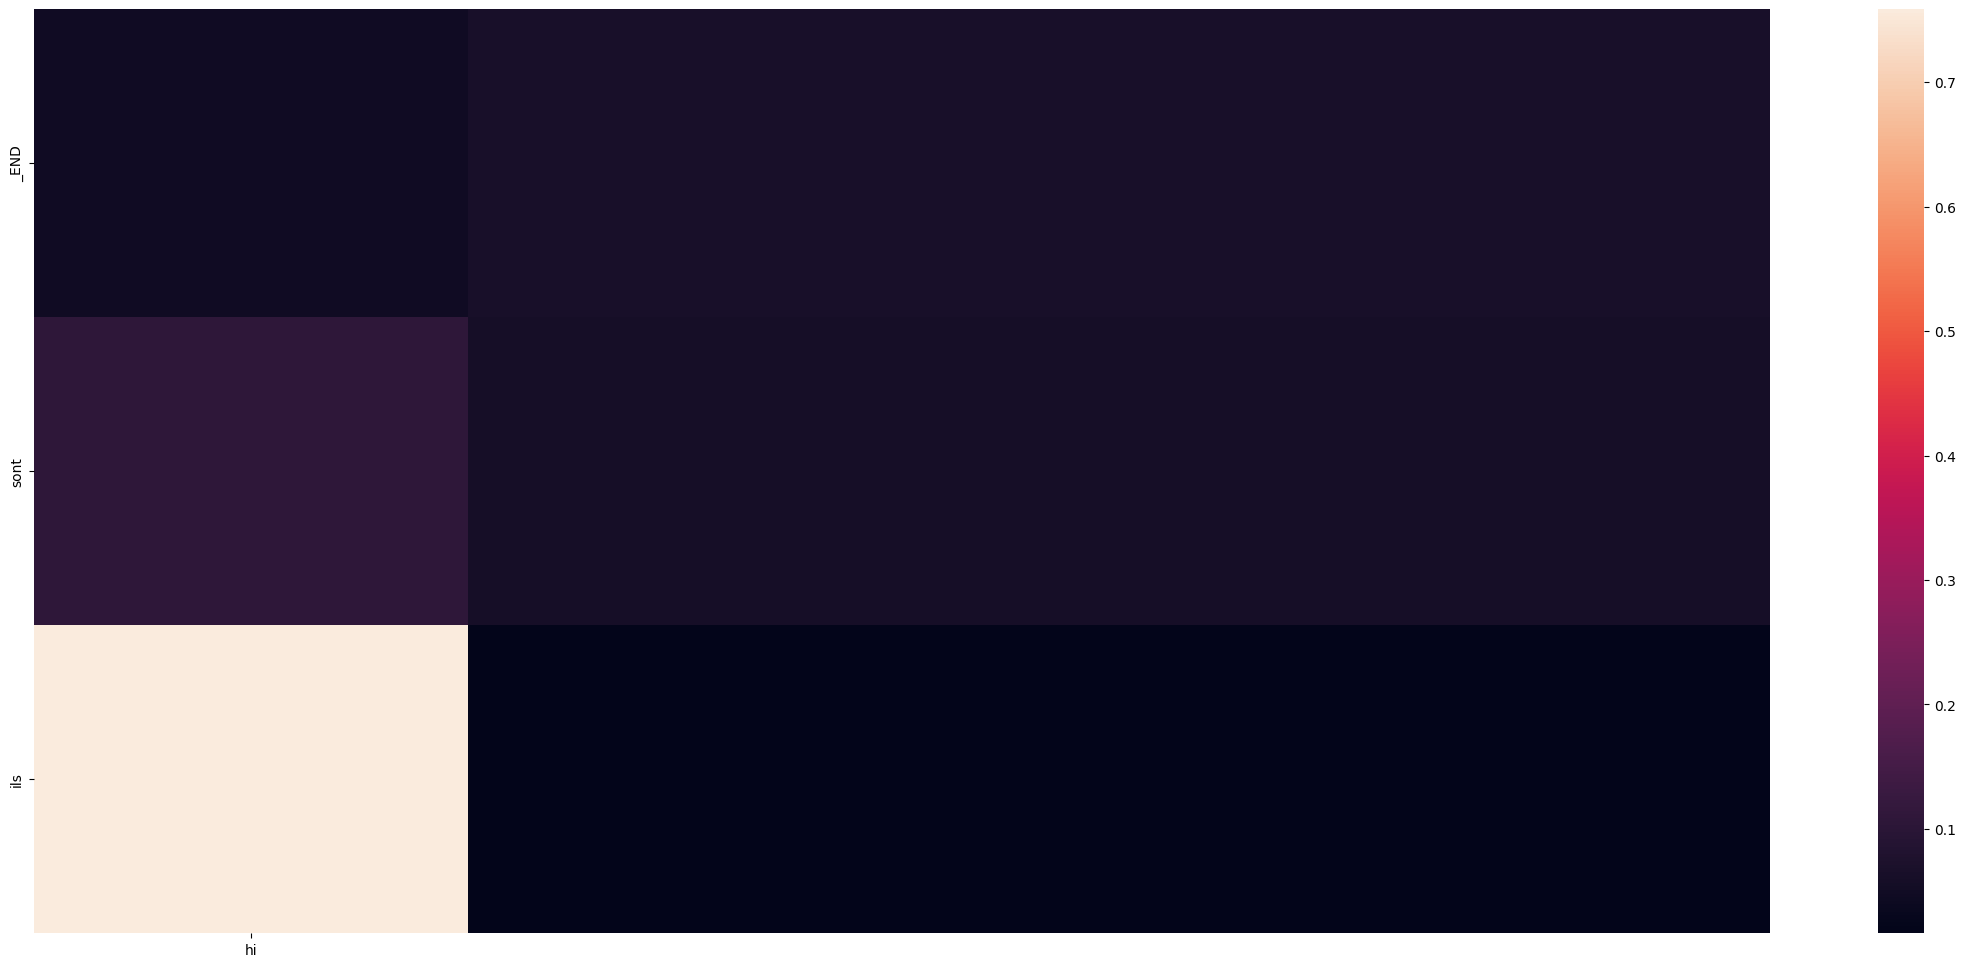

Decoded sentence:  ils sont _END
-
Input sentence: run
GT sentence: START_ cours  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


<Figure size 640x480 with 0 Axes>

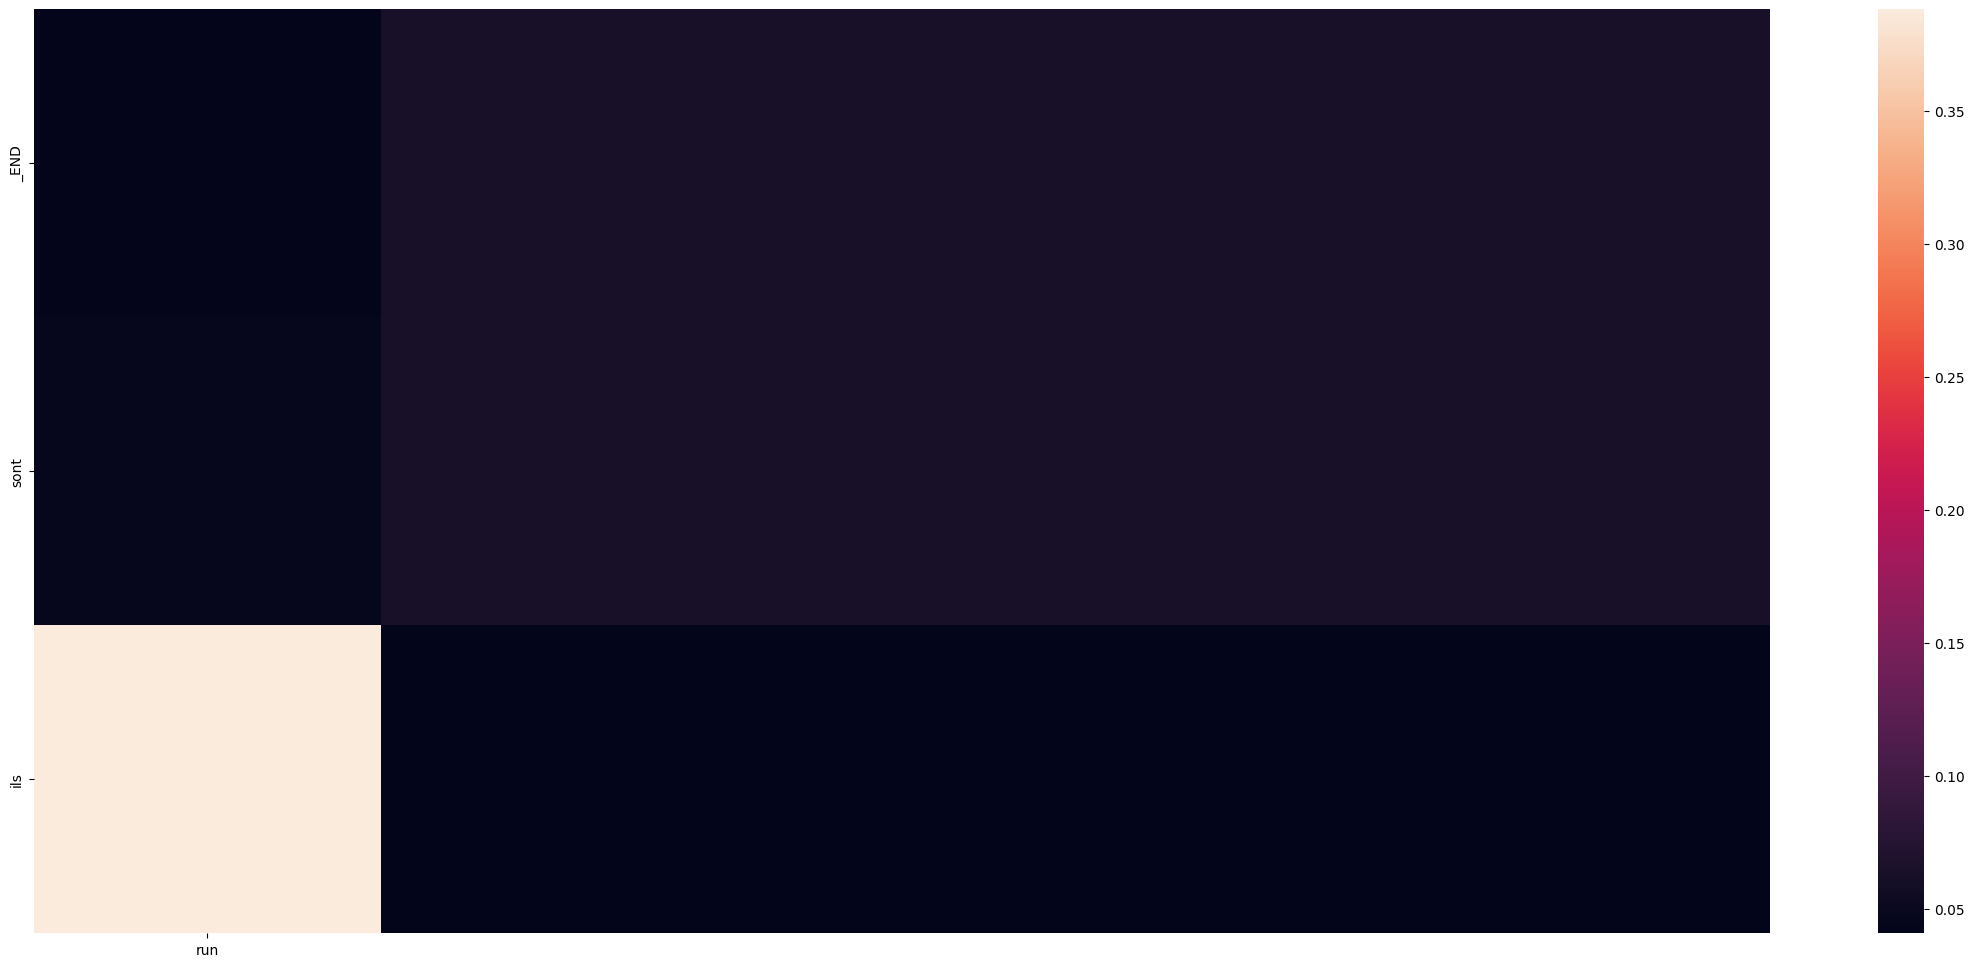

Decoded sentence:  ils sont _END
-
Input sentence: run
GT sentence: START_ courez  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


<Figure size 640x480 with 0 Axes>

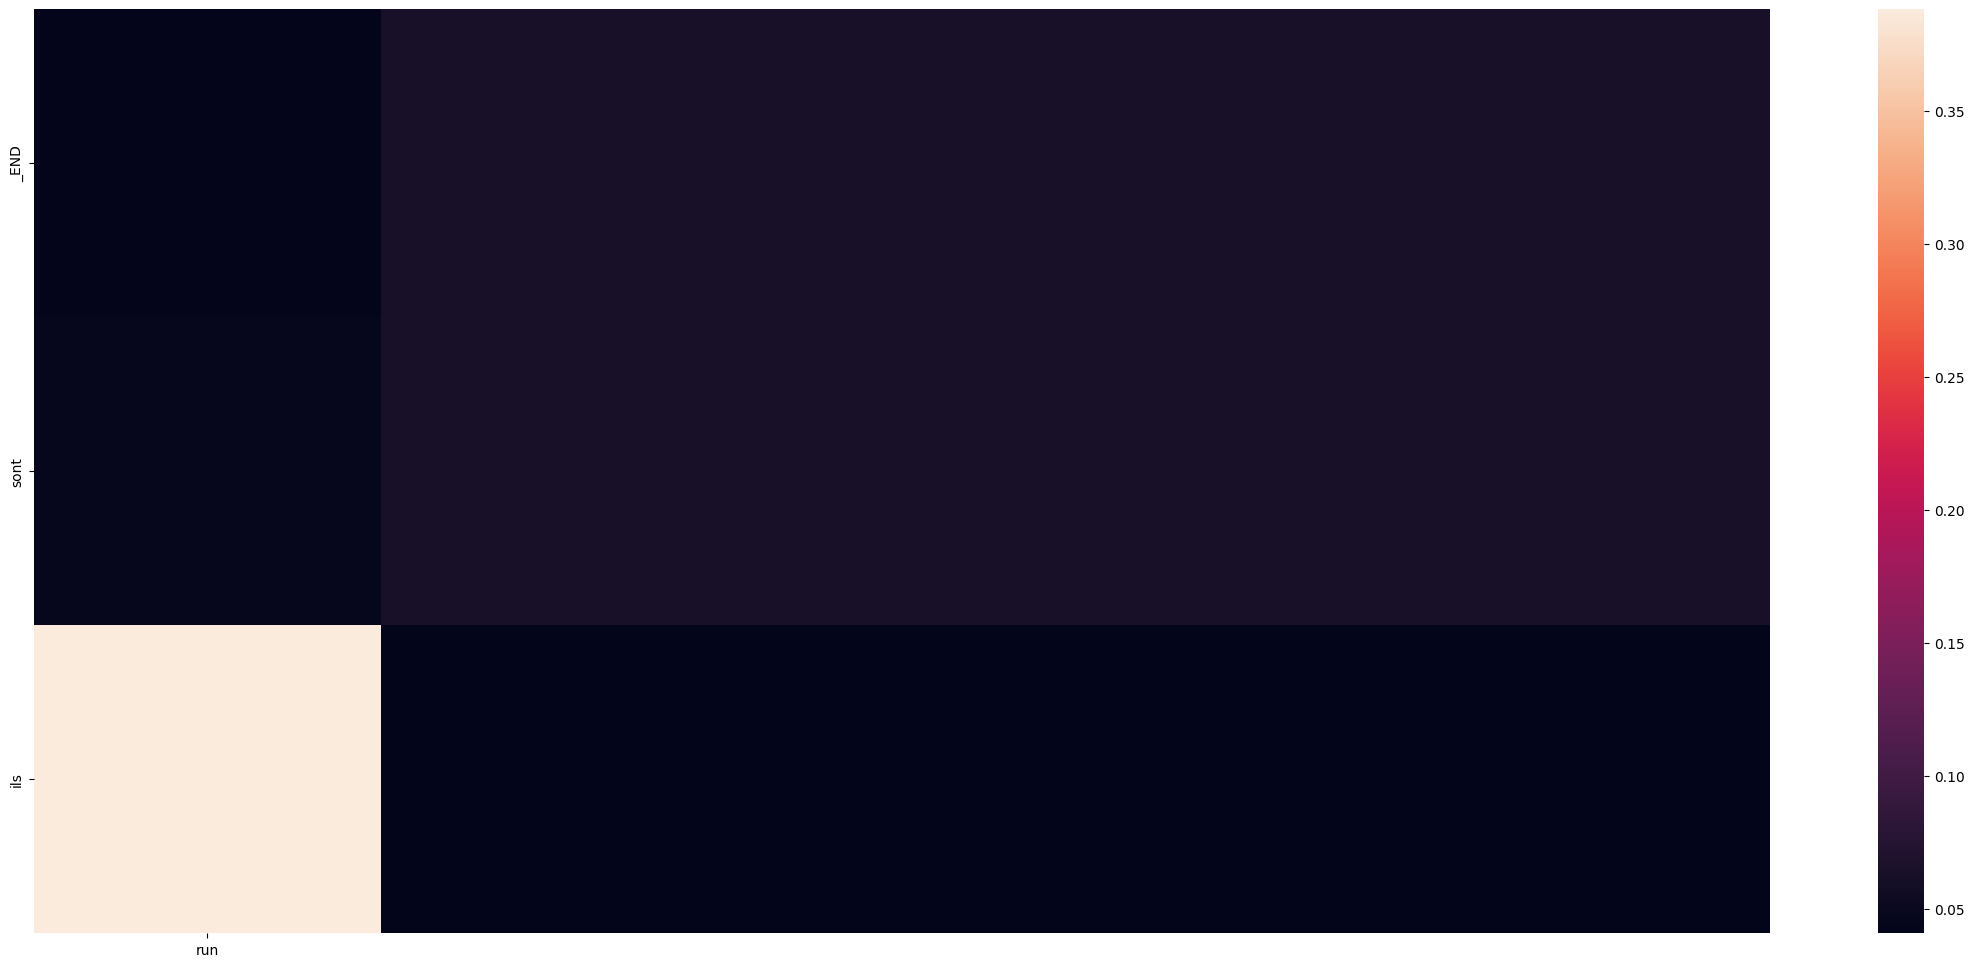

Decoded sentence:  ils sont _END
-
Input sentence: run
GT sentence: START_ prenez vos jambes à vos cous  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


<Figure size 640x480 with 0 Axes>

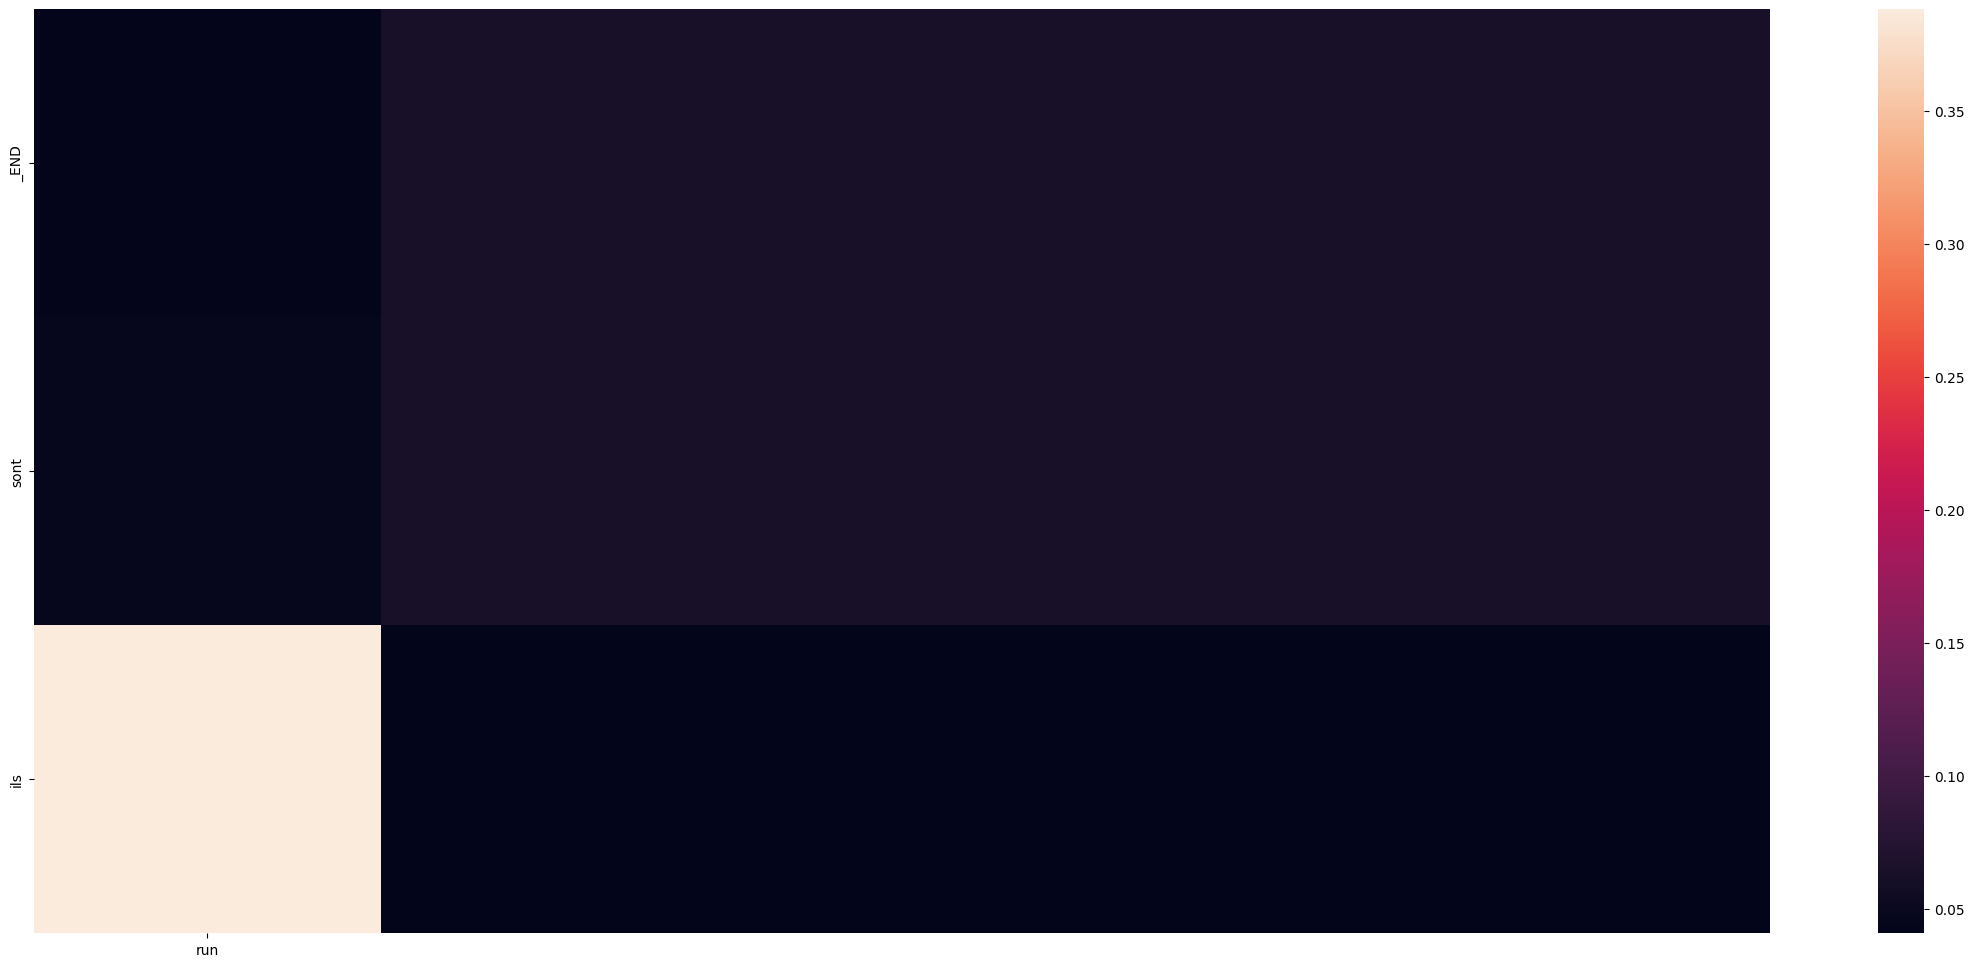

Decoded sentence:  ils sont _END
-
Input sentence: run
GT sentence: START_ file  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


<Figure size 640x480 with 0 Axes>

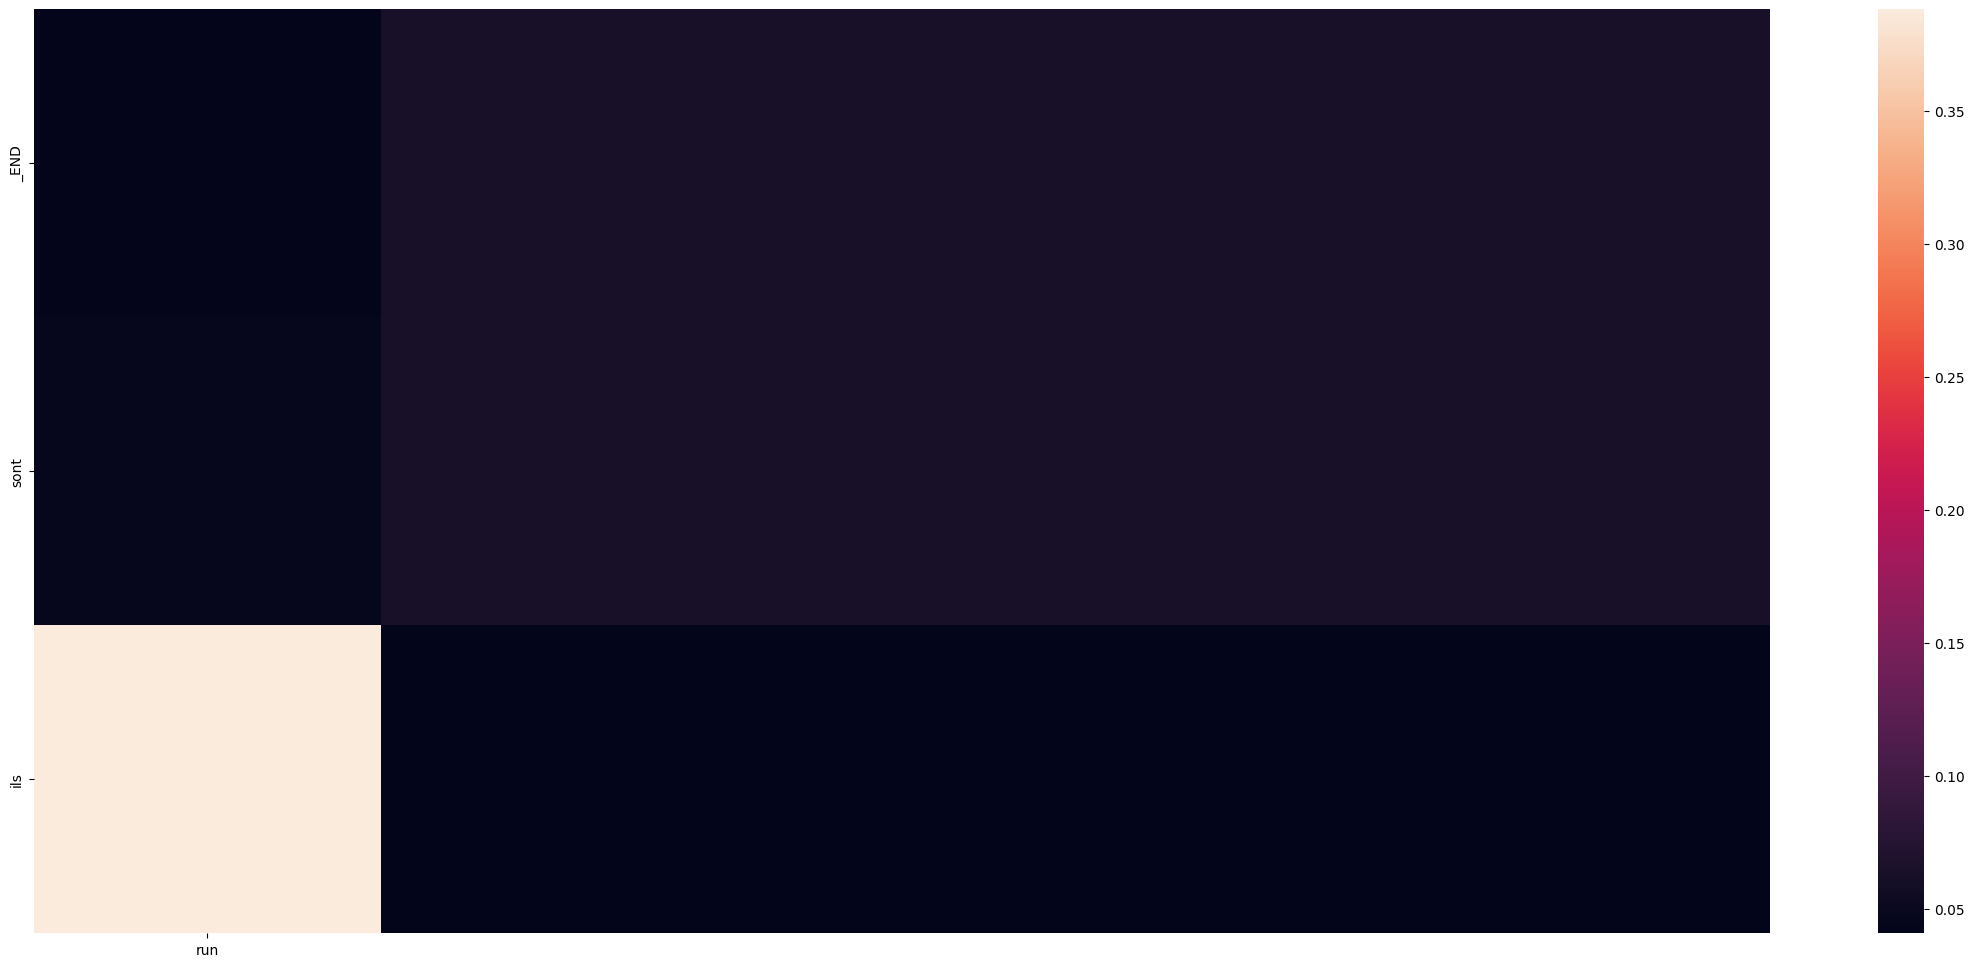

Decoded sentence:  ils sont _END
-
Input sentence: run
GT sentence: START_ filez  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


<Figure size 640x480 with 0 Axes>

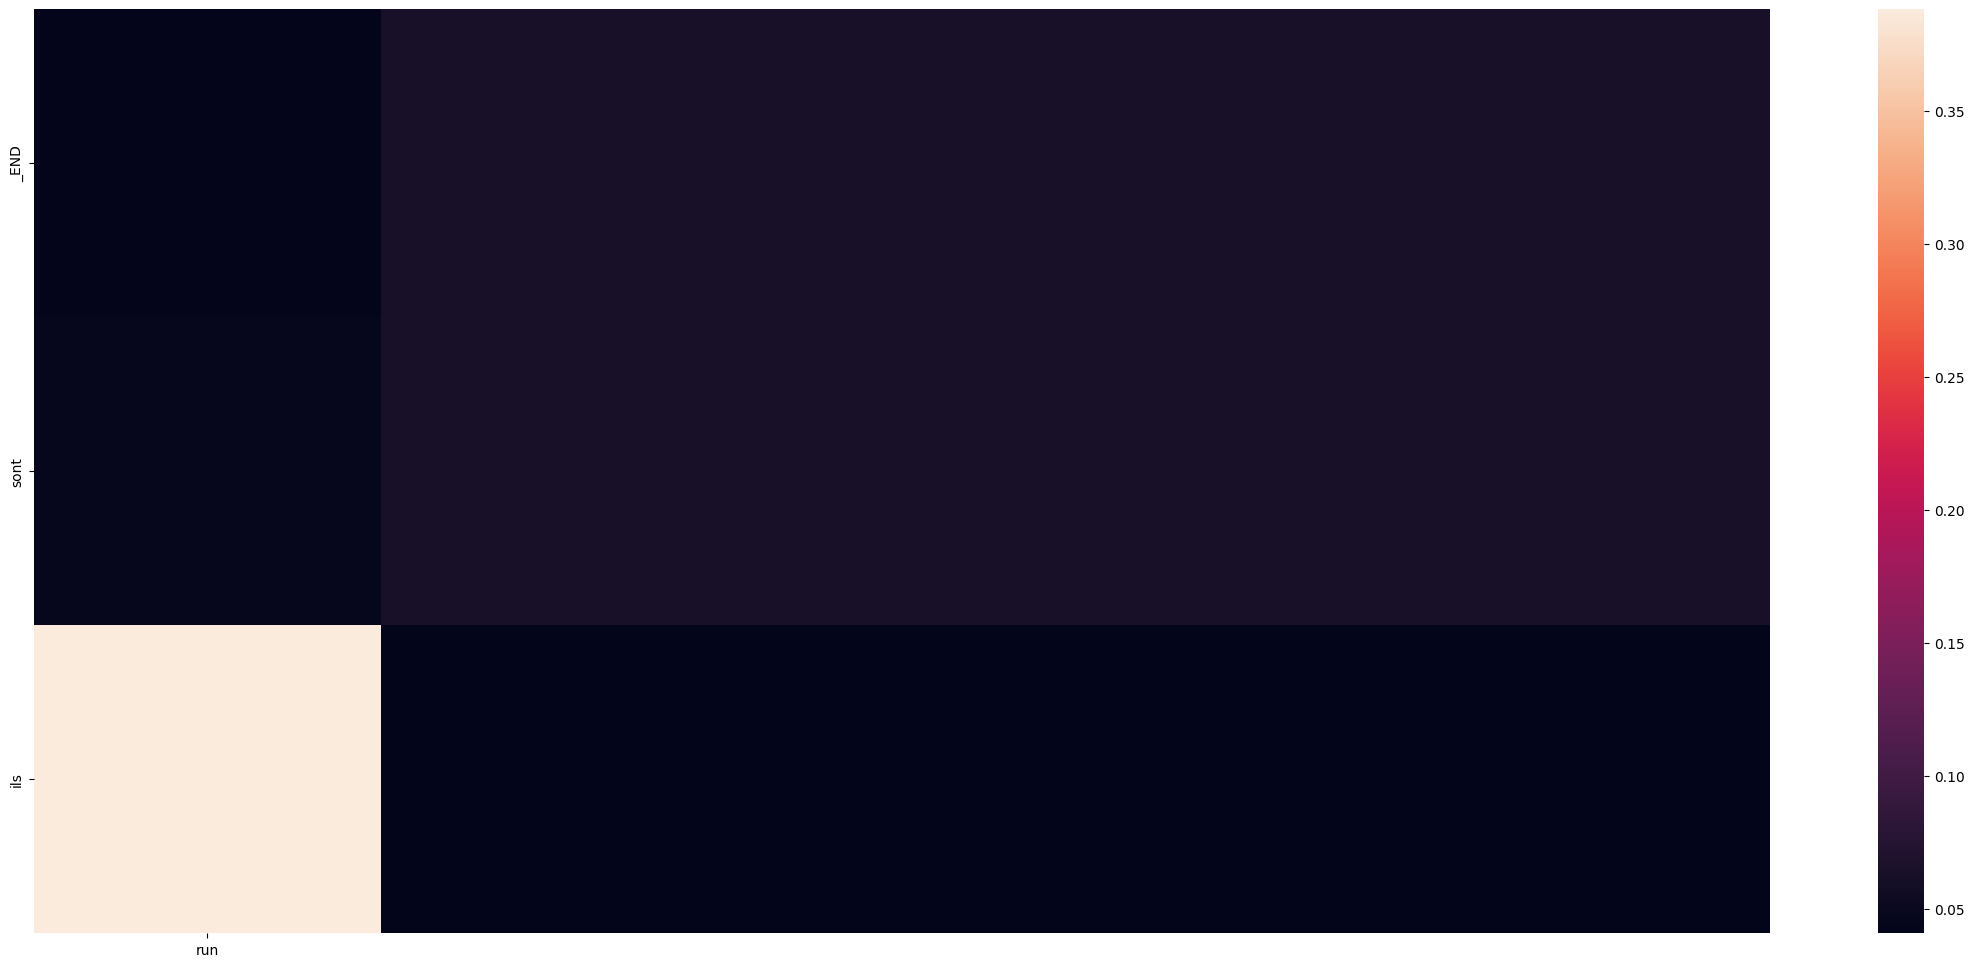

Decoded sentence:  ils sont _END
-
Input sentence: run
GT sentence: START_ cours  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


<Figure size 640x480 with 0 Axes>

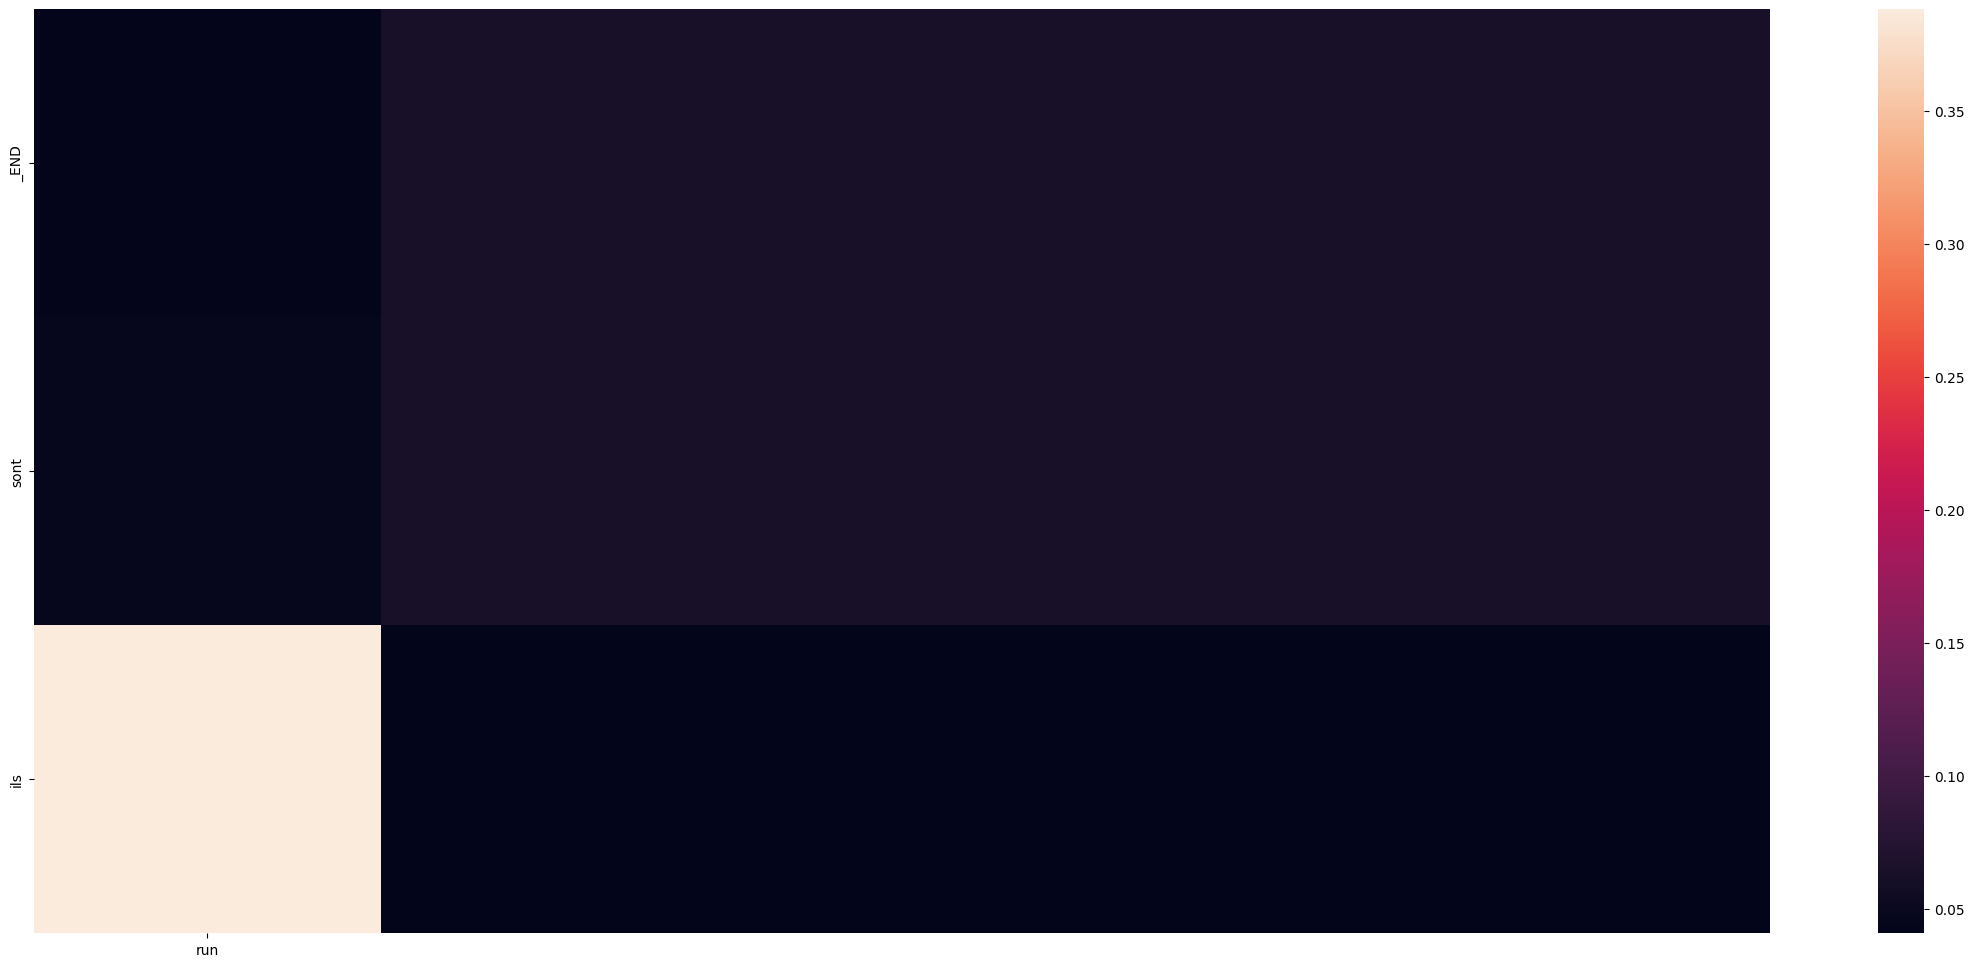

Decoded sentence:  ils sont _END
-
Input sentence: run
GT sentence: START_ fuyez  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


<Figure size 640x480 with 0 Axes>

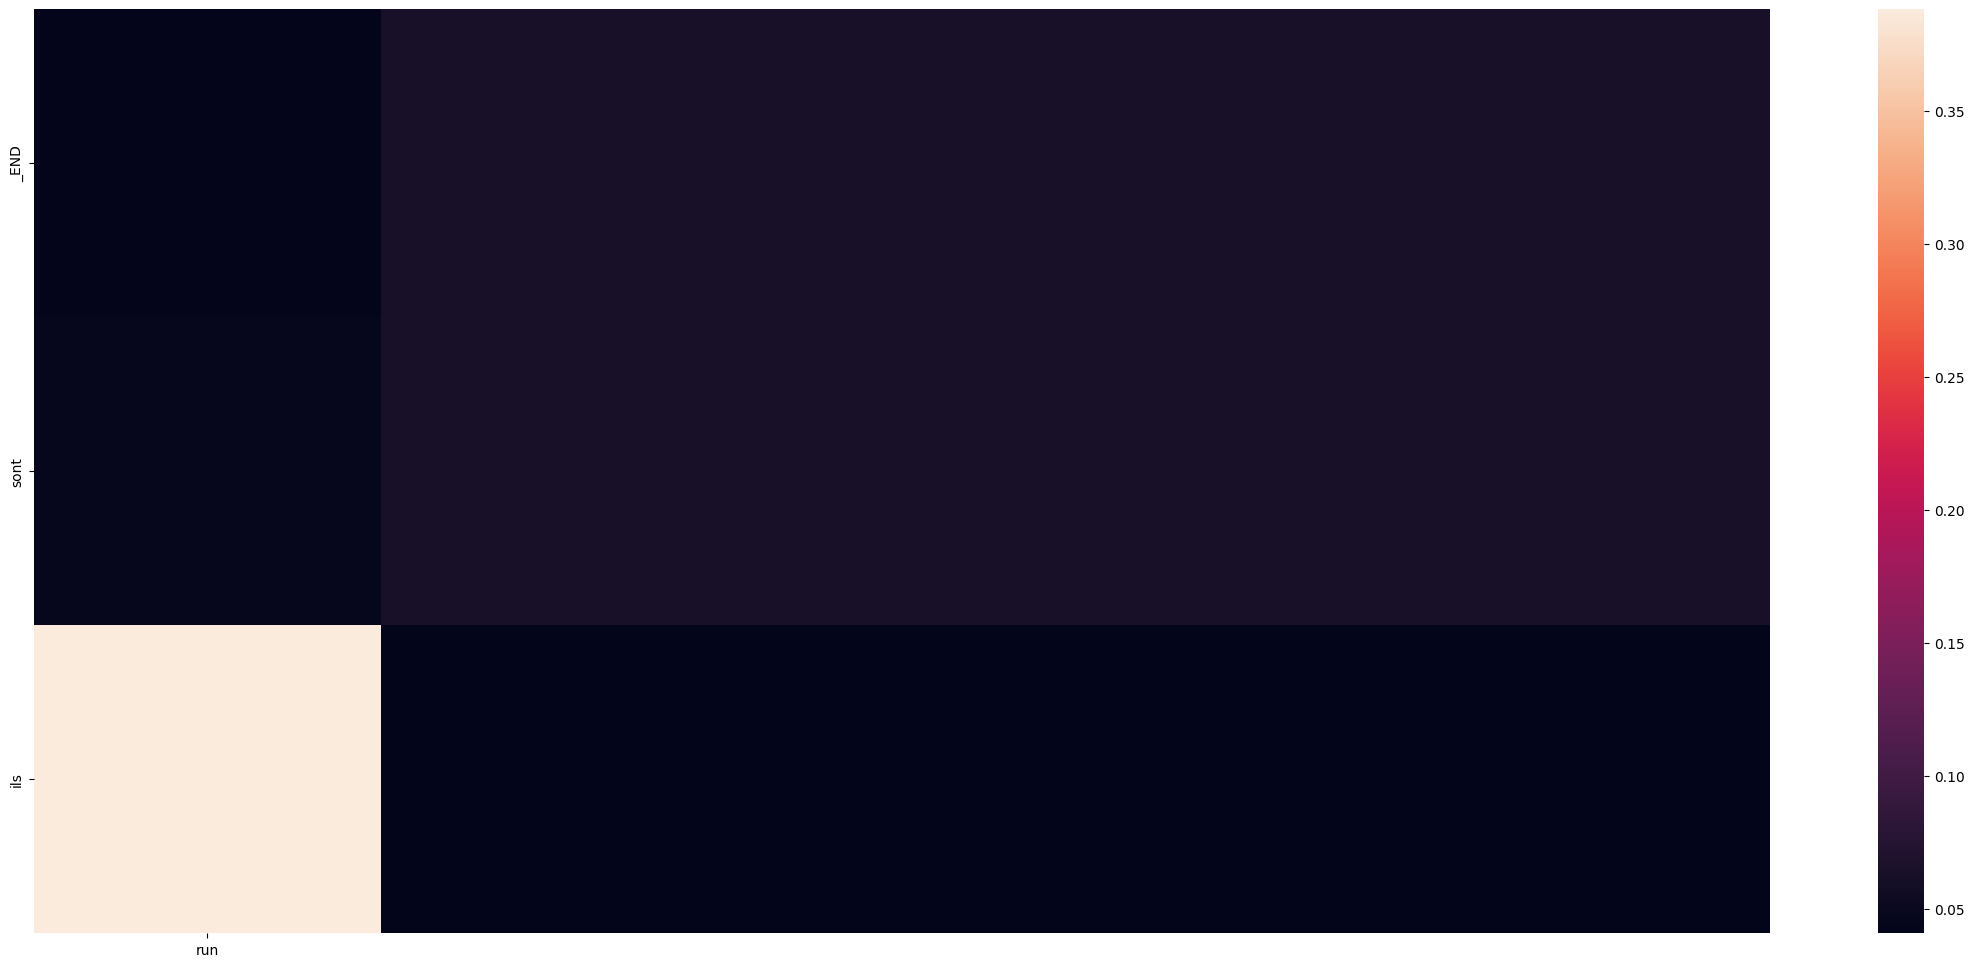

Decoded sentence:  ils sont _END
-
Input sentence: run
GT sentence: START_ fuyons  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


<Figure size 640x480 with 0 Axes>

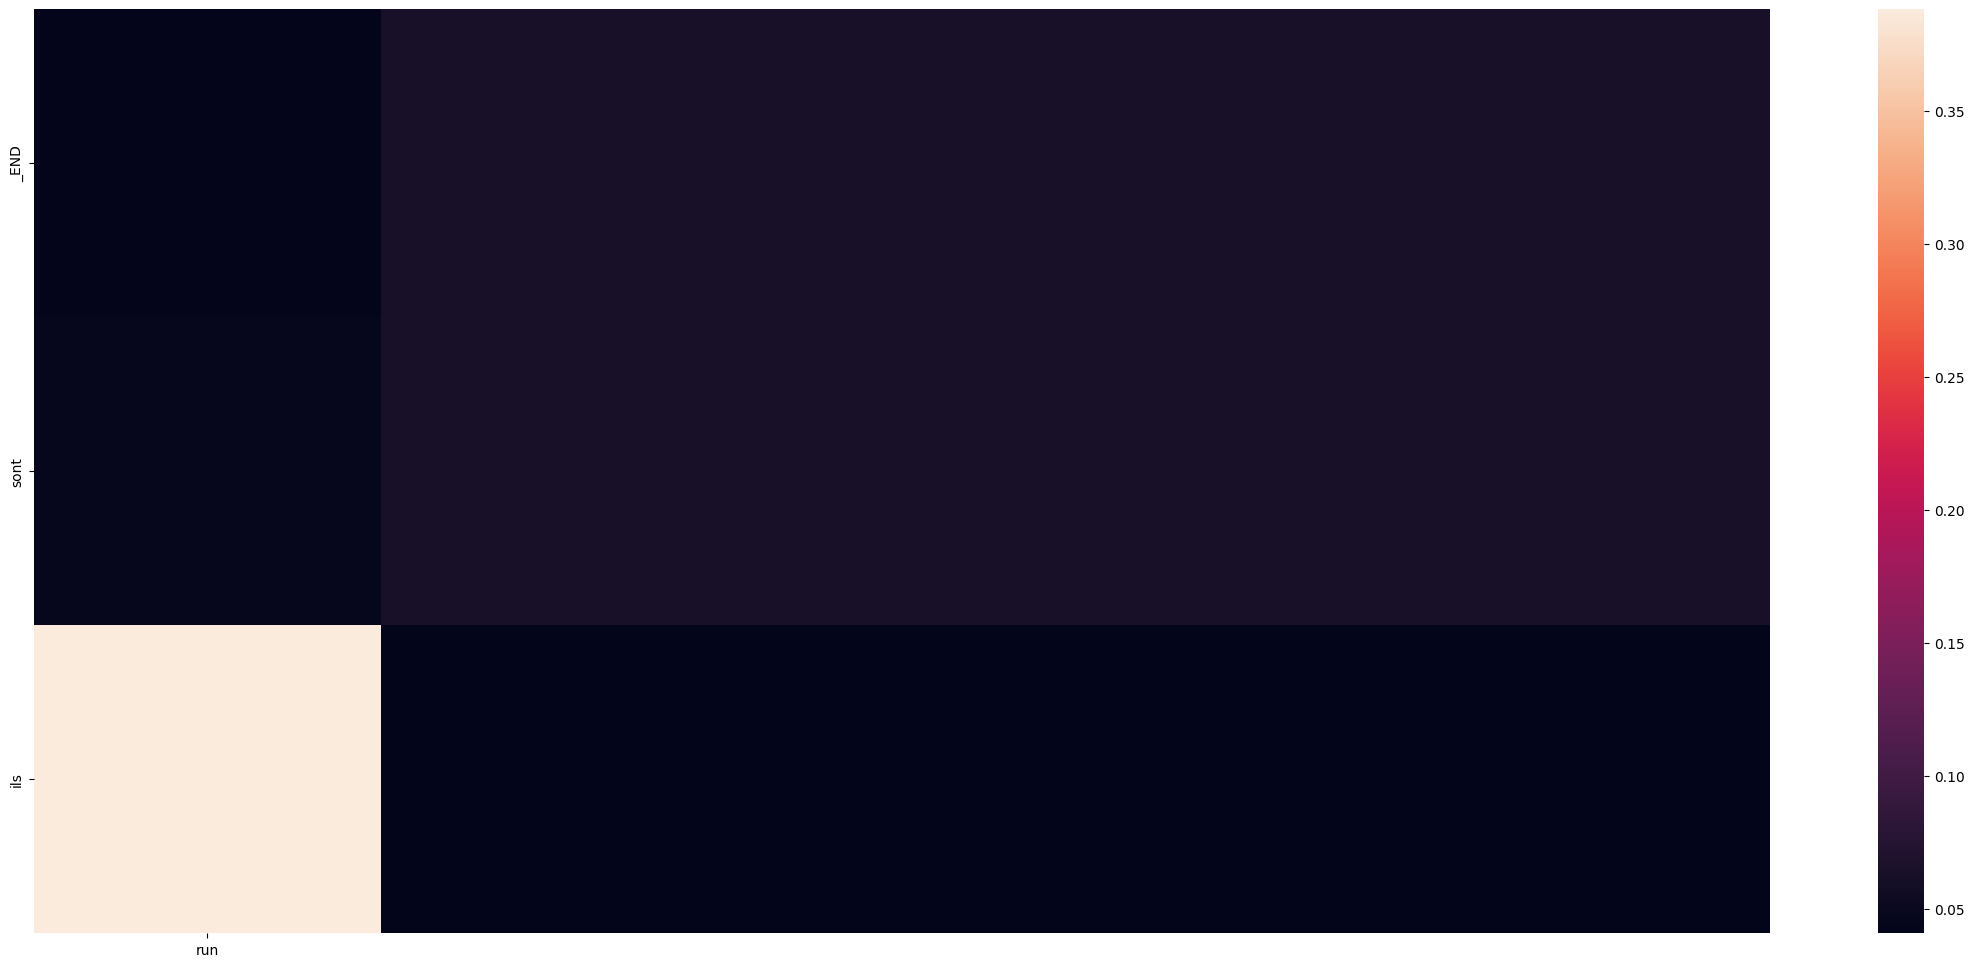

Decoded sentence:  ils sont _END
-
Input sentence: run
GT sentence: START_ cours  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


<Figure size 640x480 with 0 Axes>

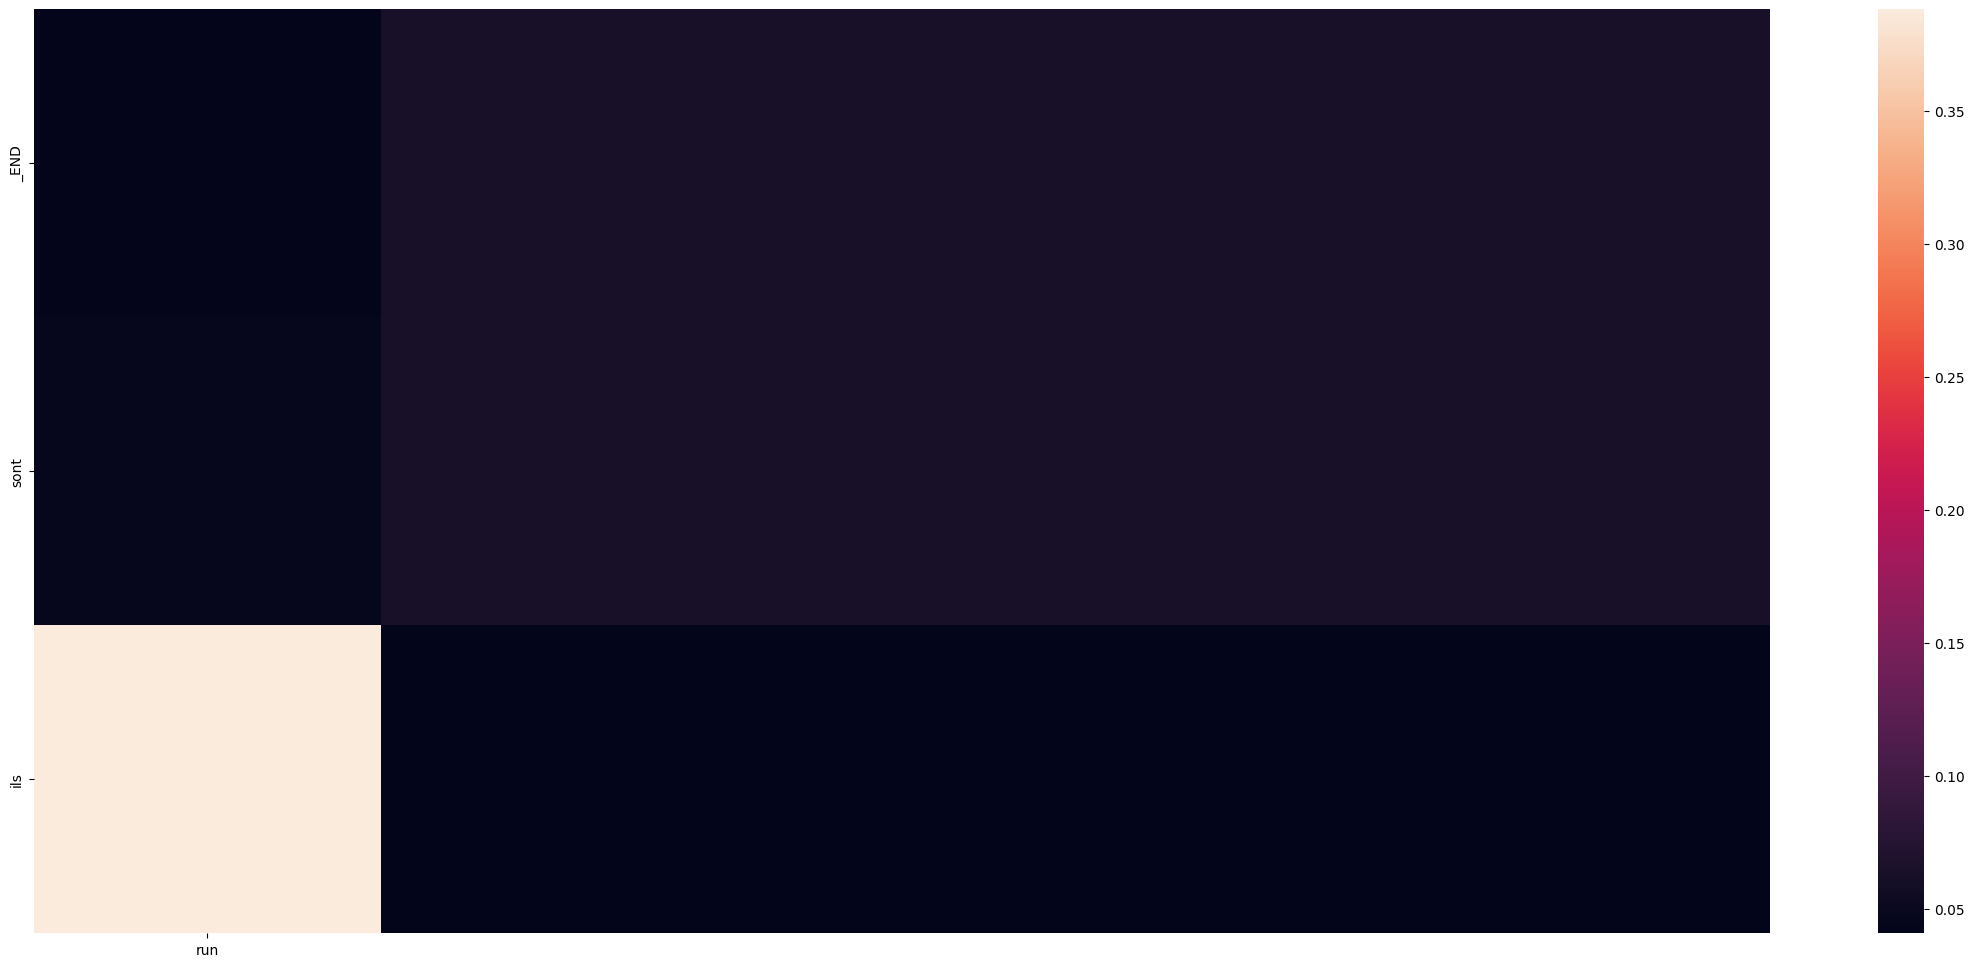

Decoded sentence:  ils sont _END
-
Input sentence: run
GT sentence: START_ courez  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


<Figure size 640x480 with 0 Axes>

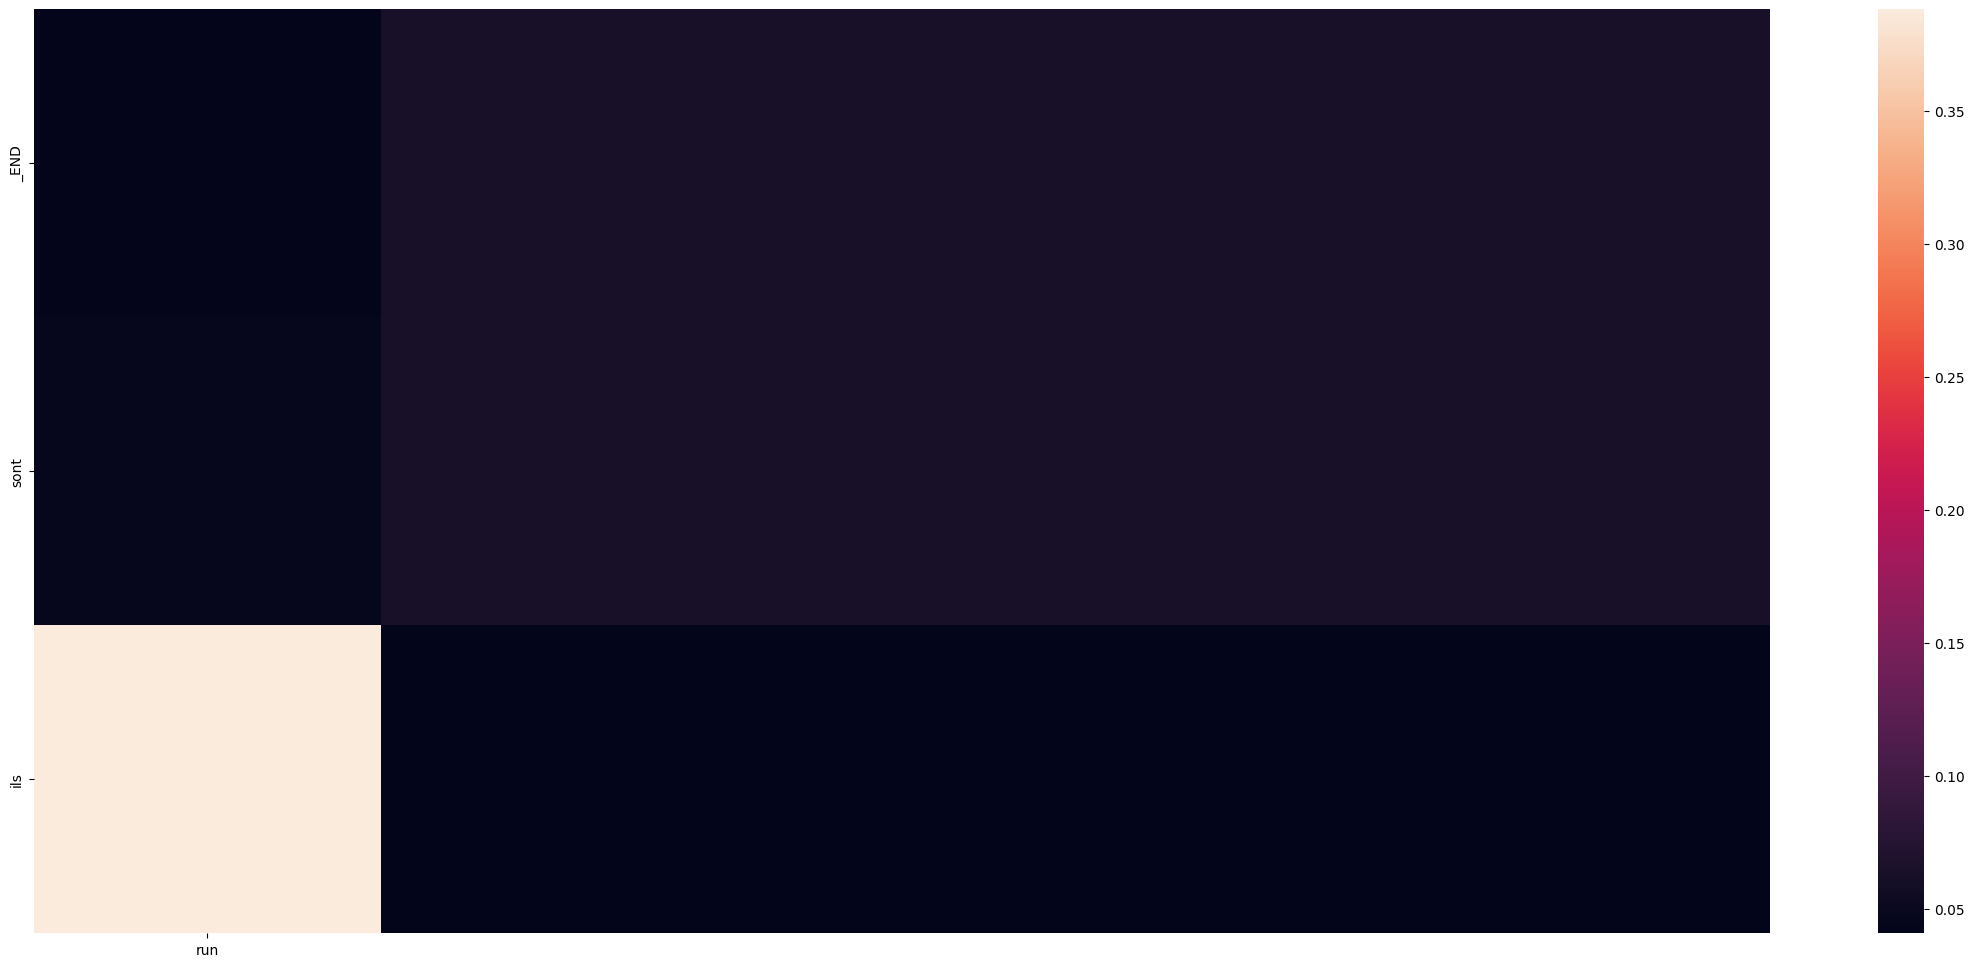

Decoded sentence:  ils sont _END
-
Input sentence: run
GT sentence: START_ prenez vos jambes à vos cous  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


<Figure size 640x480 with 0 Axes>

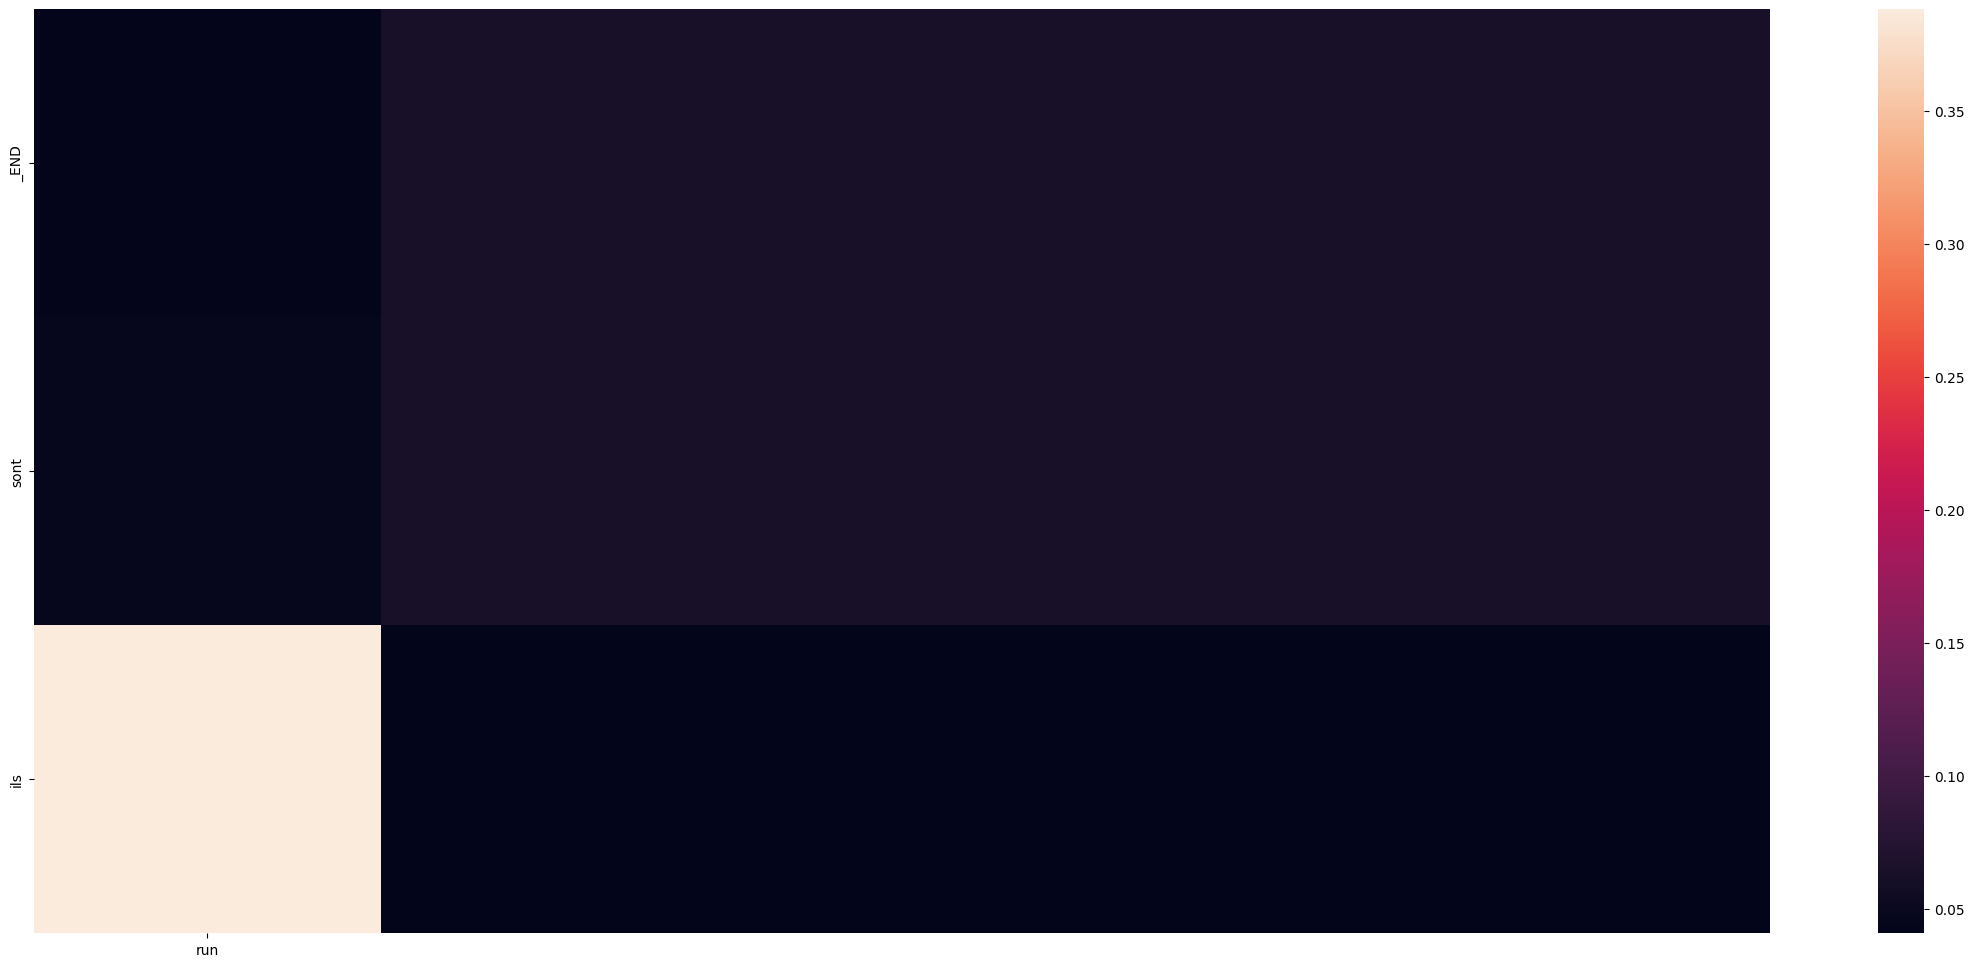

Decoded sentence:  ils sont _END
-
Input sentence: run
GT sentence: START_ file  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


<Figure size 640x480 with 0 Axes>

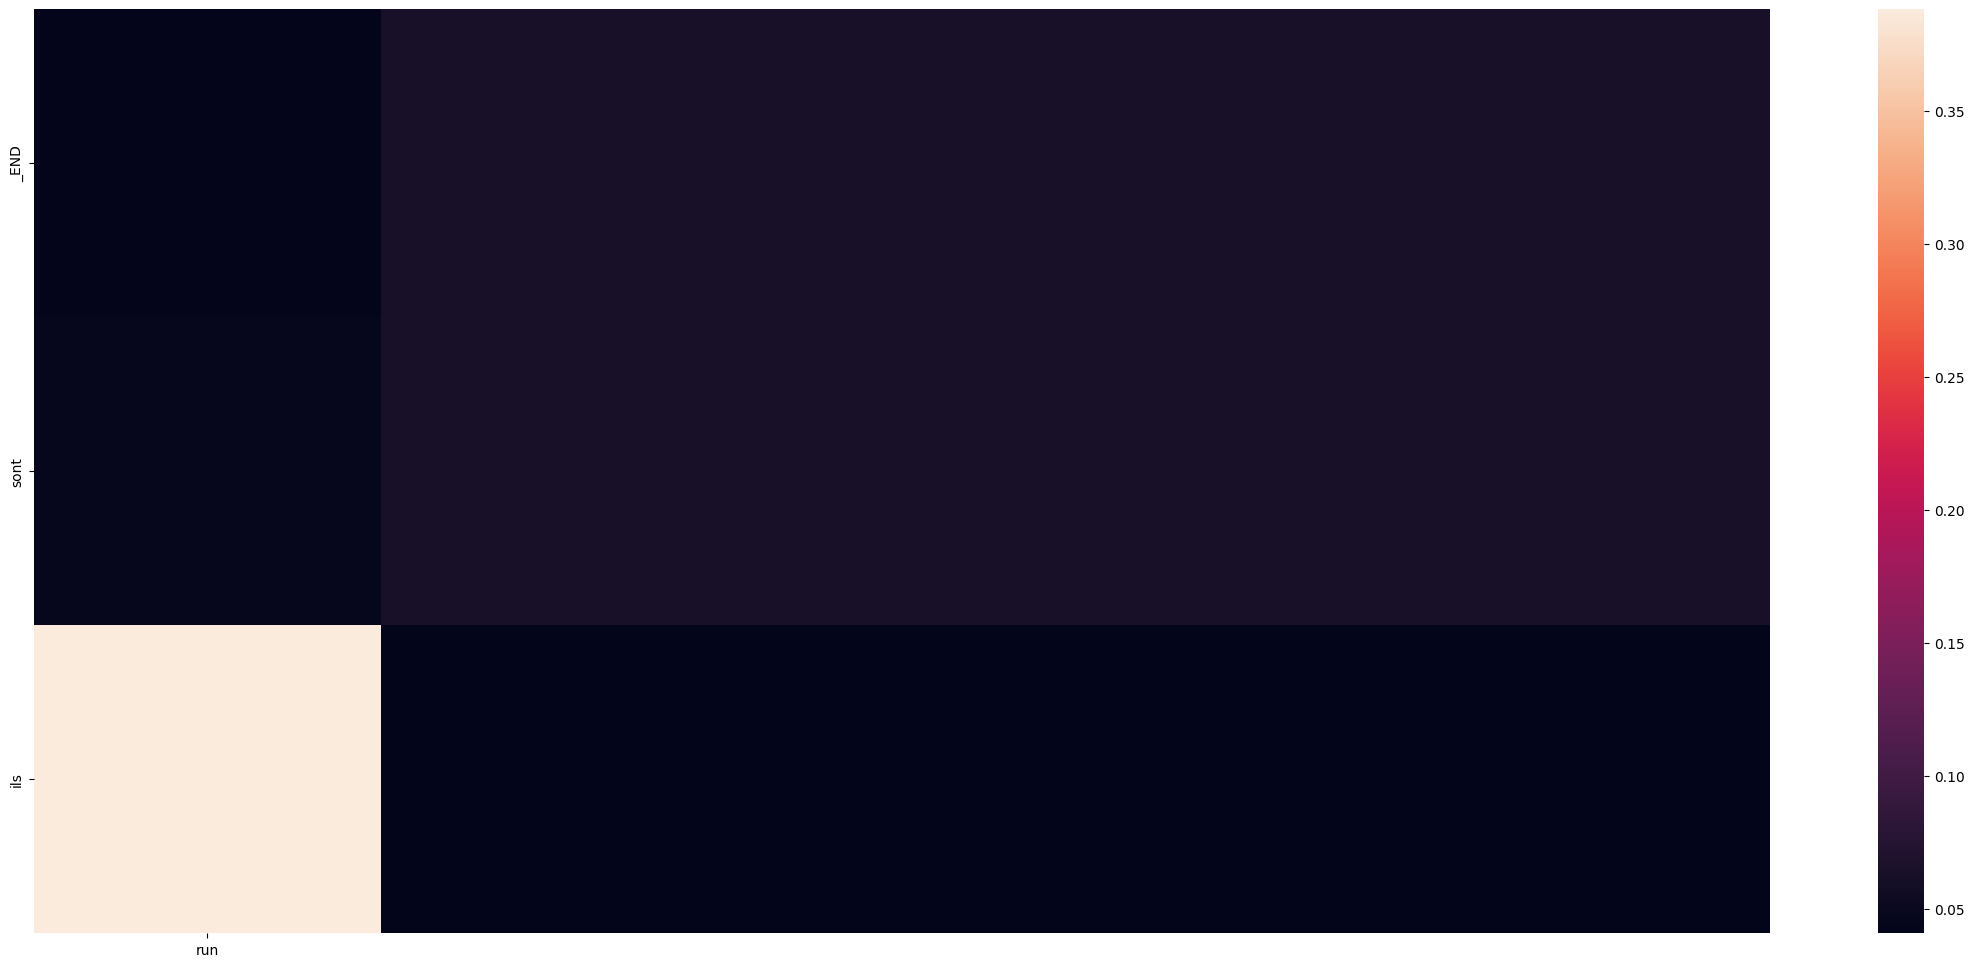

Decoded sentence:  ils sont _END
-
Input sentence: run
GT sentence: START_ filez  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


<Figure size 640x480 with 0 Axes>

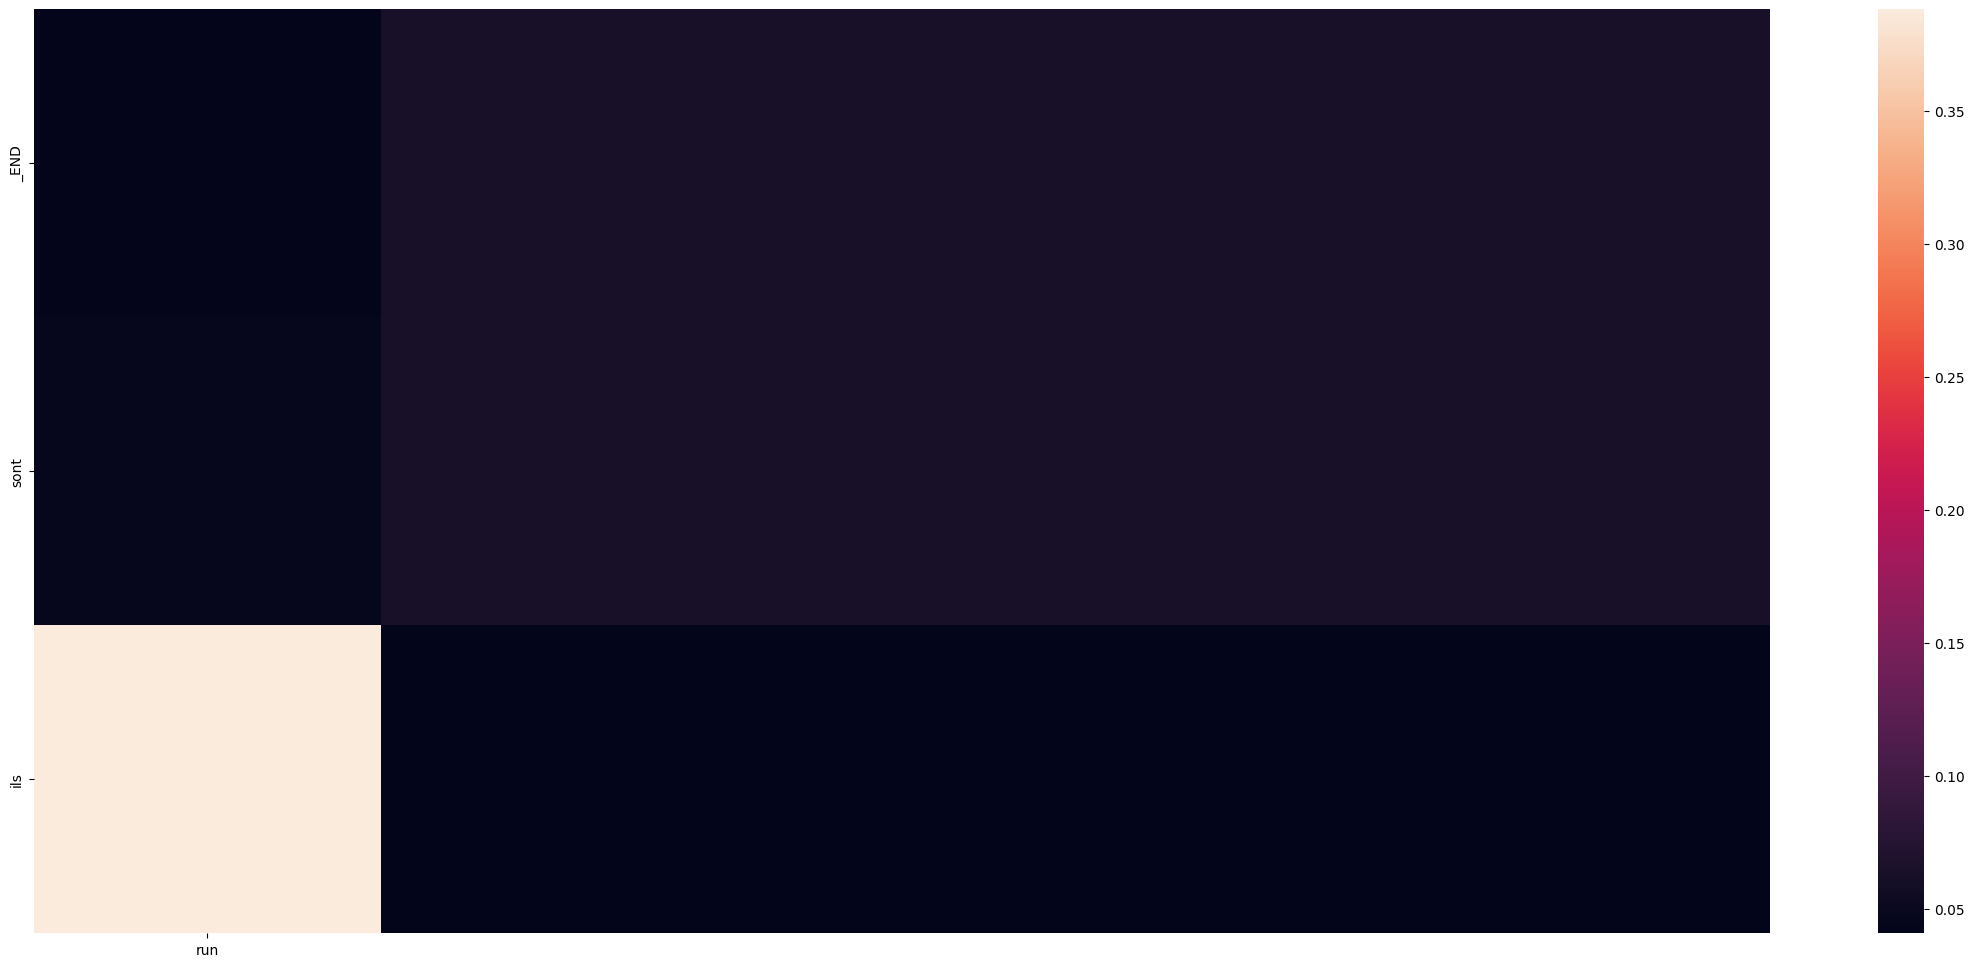

Decoded sentence:  ils sont _END
-
Input sentence: run
GT sentence: START_ cours  _END
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


<Figure size 640x480 with 0 Axes>

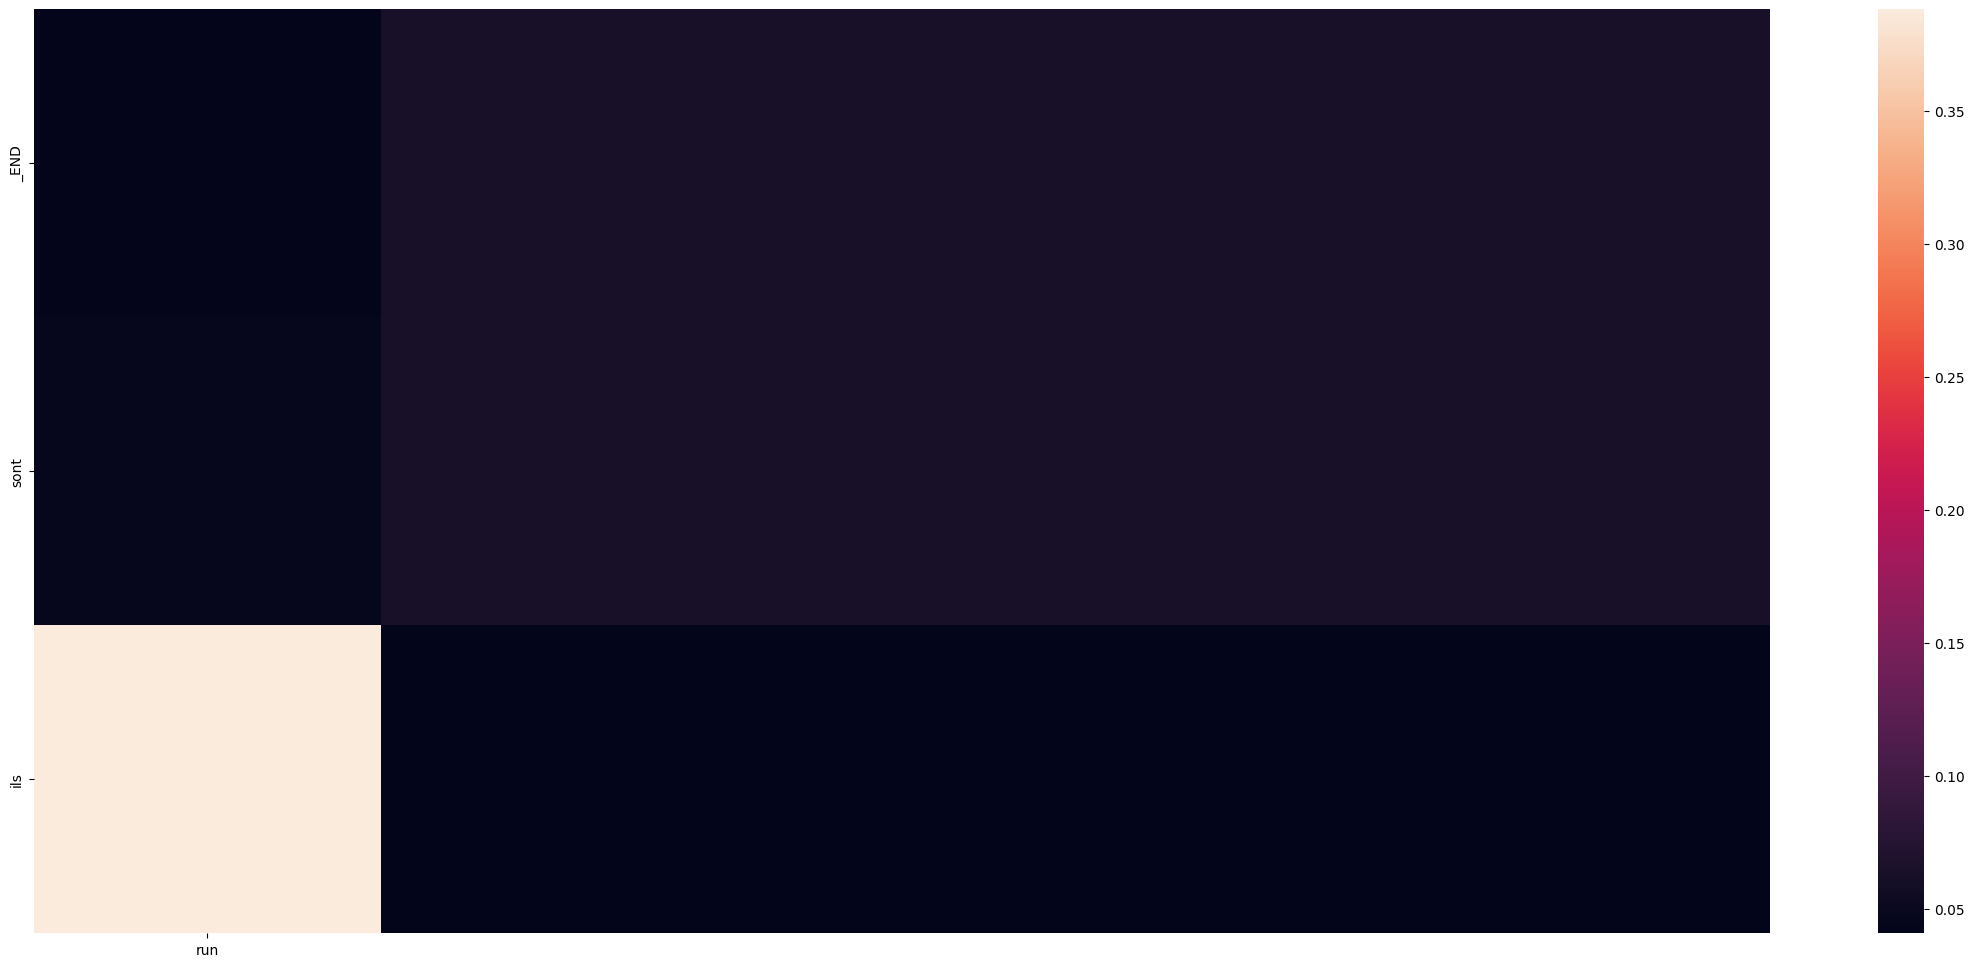

Decoded sentence:  ils sont _END


In [26]:
for seq_index in range(20):

    target_text = lines.target[seq_index]
    text = lines.input[seq_index]
    print('-')
    print('Input sentence:', text)
    print('GT sentence:', target_text)
    decoded_sentence = visualize_attention(text, encoder_model, decoder_model, max_encoder_seq_length, num_decoder_tokens, input_token_index, reverse_target_tok_index, tok_split_word2word)


    print('Decoded sentence:', decoded_sentence)


In [27]:
from nltk.translate.bleu_score import sentence_bleu

def calculate_bleu_score(reference, candidate):

  return sentence_bleu([reference], candidate)

reference_sentence = ['START_', 'i', 'love', 'you', '_END']
candidate_sentence = ['START_', 'i', 'like', 'you', '_END']  # semantically close

bleu_score = calculate_bleu_score(reference_sentence, candidate_sentence)
print(f"BLEU score: {bleu_score}")

# Calculate BLEU scores for all decoded sentences
for seq_index in range(len(word_decoded_sents)):
    reference = lines.target[seq_index].split()  # Split the reference sentence
    candidate = word_decoded_sents[seq_index].split()  # Split the candidate sentence
    bleu = calculate_bleu_score(reference, candidate)
    print(f"BLEU score for sequence {seq_index + 1}: {bleu}")


BLEU score: 1.1862800137389335e-154
BLEU score for sequence 1: 1.384292958842266e-231
BLEU score for sequence 2: 1.384292958842266e-231
BLEU score for sequence 3: 9.918892480173173e-232
BLEU score for sequence 4: 1.384292958842266e-231
BLEU score for sequence 5: 1.384292958842266e-231
BLEU score for sequence 6: 1.384292958842266e-231
BLEU score for sequence 7: 1.384292958842266e-231
BLEU score for sequence 8: 1.384292958842266e-231
BLEU score for sequence 9: 2.614591671051252e-232
BLEU score for sequence 10: 1.384292958842266e-231
BLEU score for sequence 11: 1.384292958842266e-231
BLEU score for sequence 12: 1.384292958842266e-231
BLEU score for sequence 13: 1.384292958842266e-231
BLEU score for sequence 14: 1.384292958842266e-231
BLEU score for sequence 15: 1.384292958842266e-231


/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

In [28]:
from nltk.translate.bleu_score import sentence_bleu

def calculate_bleu_score(reference, candidate):

  return sentence_bleu([reference], candidate)

reference_sentence = ['START_', 'this', 'is', 'a', 'test', '_END']
candidate_sentence = ['START_', 'this', 'is', 'an', 'example', '_END']

bleu_score = calculate_bleu_score(reference_sentence, candidate_sentence)
print(f"BLEU score: {bleu_score}")

# Calculate BLEU scores for all decoded sentences
for seq_index in range(len(word_decoded_sents)):
    reference = lines.target[seq_index].split()  # Split the reference sentence
    candidate = word_decoded_sents[seq_index].split()  # Split the candidate sentence
    bleu = calculate_bleu_score(reference, candidate)
    print(f"BLEU score for sequence {seq_index + 1}: {bleu}")


BLEU score: 6.206021746903507e-78
BLEU score for sequence 1: 1.384292958842266e-231
BLEU score for sequence 2: 1.384292958842266e-231
BLEU score for sequence 3: 9.918892480173173e-232
BLEU score for sequence 4: 1.384292958842266e-231
BLEU score for sequence 5: 1.384292958842266e-231
BLEU score for sequence 6: 1.384292958842266e-231
BLEU score for sequence 7: 1.384292958842266e-231
BLEU score for sequence 8: 1.384292958842266e-231
BLEU score for sequence 9: 2.614591671051252e-232
BLEU score for sequence 10: 1.384292958842266e-231
BLEU score for sequence 11: 1.384292958842266e-231
BLEU score for sequence 12: 1.384292958842266e-231
BLEU score for sequence 13: 1.384292958842266e-231
BLEU score for sequence 14: 1.384292958842266e-231
BLEU score for sequence 15: 1.384292958842266e-231
